# ⚽ Decoding the DNA of Real Madrid
## A Football Analytics Investigation into La Liga Playing Styles, Clustering, and Success Factors

---

> *"Football is not just about winning — it's about understanding what separates the great from the rest."*

Prepared by:
**Oussama Id Omar**

**Dataset:** La Liga 2025/26 Season — SP1.csv  
**Central Question:** *What makes Real Madrid statistically different from other La Liga clubs, and which teams are most similar?*  
**Author:** Football Analytics Project  
**Tools:** Python · scikit-learn · pandas · matplotlib · seaborn

---

### Project Roadmap

| Section | Title | Goal |
|---------|-------|------|
| 1 | Setting the Scene | Context, motivation, dataset overview |
| 2 | Building Team DNA | Aggregate match-level → team-level statistics |
| 3 | The La Liga Landscape | EDA, visualisations, league-wide patterns |
| 4 | Feature Engineering & Selection | Professional audit, correlation, domain reasoning |
| 5 | Discovering Playing Styles (K-Means / K-Means++) | Cluster La Liga teams by how they play |
| 6 | The Full Tactical Map (Hierarchical + DBSCAN) | Dendrograms, outlier detection |
| 7 | Where Does Real Madrid Belong? | Cluster membership, PCA, nearest neighbours (KNN) |
| 8 | What Drives Success? (Decision Tree + Logistic Reg.) | Key performance indicators for winning |
| 9 | Ensemble Intelligence (Random Forest + AdaBoost + Stacking) | Best predictive model |
| 10 | Model Comparison | Head-to-head evaluation |
| 11 | Final Football Insights | Synthesis & analyst's verdict |


##  — Libraries & Configuration

In [79]:
# ── Install any missing libraries (safe to re-run in Colab) ──────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'scikit-learn', 'seaborn', 'matplotlib', 'pandas',
                       'numpy', 'scipy', 'mlxtend'])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
from scipy.stats import zscore

# ── Sklearn: preprocessing ────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Sklearn: clustering ───────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                               calinski_harabasz_score)

# ── Sklearn: classification ───────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression

# ── Sklearn: ensembles ────────────────────────────────────────────────────────
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               StackingClassifier, GradientBoostingClassifier)

# ── Sklearn: metrics ──────────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

# ── Global style ──────────────────────────────────────────────────────────────
# Real Madrid brand colours
RM_WHITE  = '#FAFAFA'
RM_GOLD   = '#C8A951'
RM_NAVY   = '#0B2C5E'
RM_PURPLE = '#6C3082'   # LaLiga accent

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})
RANDOM_STATE = 42

print('✅ All libraries imported successfully.')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')


✅ All libraries imported successfully.
   pandas 2.2.2 | numpy 2.0.2


---
##  — Setting the Scene

### Why Football Analytics?

The modern game is driven by data. Clubs like Barcelona pioneered possession metrics. Liverpool used Expected Goals (xG) to rebuild their attack. Real Madrid have long dominated through a combination of individual brilliance and collective tactical coherence.

This project uses machine learning as a **lens** to examine La Liga from the inside — not just predicting results, but understanding the structural differences between clubs: their tactical DNA.

### Why La Liga?

La Liga is one of the world's most analytically interesting leagues:
- 20 clubs with radically different budgets and philosophies
- High variance in playing styles (from Getafe's physicality to Barça's possession)
- Clear distinction between elite, mid-table, and survival clubs

### The Central Question

> **"What makes Real Madrid statistically different from other La Liga clubs, and which teams are most similar?"**

This single question will drive every section of this analysis.


In [80]:
import pandas as pd

# ── Load dataset ──────────────────────────────────────────────────────────────
# In Google Colab: upload SP1.csv when prompted, or mount Google Drive.
# from google.colab import files
# uploaded = files.upload()

df_raw = pd.read_csv('/content/SP1.csv')

print('=' * 65)
print('  LA LIGA 2025/26 — DATASET OVERVIEW')
print('=' * 65)
print(f'  Matches loaded : {len(df_raw)}')
print(f'  Total columns  : {df_raw.shape[1]}')
print(f'  Date range     : {df_raw["Date"].min()} → {df_raw["Date"].max()}')
print(f'  Teams          : {df_raw["HomeTeam"].nunique()}')
print()

teams_sorted = sorted(df_raw['HomeTeam'].unique())
print('  Clubs in dataset:')
for i, t in enumerate(teams_sorted, 1):
    marker = ' ⭐' if t == 'Real Madrid' else ''
    print(f'    {i:2d}. {t}{marker}')

print()
rm_home = df_raw[df_raw['HomeTeam'] == 'Real Madrid']
rm_away = df_raw[df_raw['AwayTeam'] == 'Real Madrid']
rm_all  = pd.concat([rm_home, rm_away])
print(f'  Real Madrid matches: {len(rm_all)} ({len(rm_home)} home, {len(rm_away)} away)')
print()
print(f'  Result distribution (FTR):')
print(df_raw['FTR'].value_counts().to_frame('Count').T)


  LA LIGA 2025/26 — DATASET OVERVIEW
  Matches loaded : 380
  Total columns  : 131
  Date range     : 01/02/2026 → 31/10/2025
  Teams          : 20

  Clubs in dataset:
     1. Alaves
     2. Ath Bilbao
     3. Ath Madrid
     4. Barcelona
     5. Betis
     6. Celta
     7. Elche
     8. Espanol
     9. Getafe
    10. Girona
    11. Levante
    12. Mallorca
    13. Osasuna
    14. Oviedo
    15. Real Madrid ⭐
    16. Sevilla
    17. Sociedad
    18. Valencia
    19. Vallecano
    20. Villarreal

  Real Madrid matches: 38 (19 home, 19 away)

  Result distribution (FTR):
FTR      H    A   D
Count  186  101  93


---
##  — Building Team DNA

Before applying any algorithm, we must construct **team-level statistics**.  
The raw dataset has one row per match. We need to aggregate into one row per team.

### Methodology
- Each club appears as both Home and Away team
- We compute per-game averages across all matches
- We separate **offensive**, **defensive**, and **discipline** indicators
- This gives us each club's statistical "fingerprint" — their DNA


In [81]:
# ── Keep only football-statistics columns ─────────────────────────────────────
FOOTBALL_COLS = [
    'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG',     # Full-time goals
    'HTHG', 'HTAG',     # Half-time goals
    'HS',   'AS',       # Shots
    'HST',  'AST',      # Shots on target
    'HF',   'AF',       # Fouls committed
    'HC',   'AC',       # Corners won
    'HY',   'AY',       # Yellow cards
    'HR',   'AR',       # Red cards
    'HTR',  'FTR'       # Results
]

df = df_raw[FOOTBALL_COLS].copy()
df.dropna(inplace=True)
print(f'Clean match-level dataset: {df.shape[0]} rows × {df.shape[1]} columns')


Clean match-level dataset: 380 rows × 20 columns


In [82]:
# ── Aggregate statistics for each team ────────────────────────────────────────
# We compute averages from both home and away perspectives.

teams = sorted(df['HomeTeam'].unique())
records = []

for team in teams:
    home = df[df['HomeTeam'] == team]
    away = df[df['AwayTeam'] == team]
    n    = len(home) + len(away)

    # Goals scored and conceded
    goals_scored    = (home['FTHG'].sum() + away['FTAG'].sum()) / n
    goals_conceded  = (home['FTAG'].sum() + away['FTHG'].sum()) / n

    # Shots
    shots_for       = (home['HS'].sum()   + away['AS'].sum())   / n
    shots_against   = (home['AS'].sum()   + away['HS'].sum())   / n

    # Shots on target
    sot_for         = (home['HST'].sum()  + away['AST'].sum())  / n
    sot_against     = (home['AST'].sum()  + away['HST'].sum())  / n

    # Conversion rate: goals per shot on target
    conv_rate       = goals_scored / sot_for if sot_for > 0 else 0

    # Corners
    corners_for     = (home['HC'].sum()   + away['AC'].sum())   / n
    corners_against = (home['AC'].sum()   + away['HC'].sum())   / n

    # Fouls
    fouls_committed = (home['HF'].sum()   + away['AF'].sum())   / n
    fouls_suffered  = (home['AF'].sum()   + away['HF'].sum())   / n

    # Discipline
    yellow_cards    = (home['HY'].sum()   + away['AY'].sum())   / n
    red_cards       = (home['HR'].sum()   + away['AR'].sum())   / n

    # Half-time goals
    ht_goals_scored   = (home['HTHG'].sum() + away['HTAG'].sum()) / n
    ht_goals_conceded = (home['HTAG'].sum() + away['HTHG'].sum()) / n

    # Win/Draw/Loss record
    wins   = (home[home['FTR']=='H'].shape[0] + away[away['FTR']=='A'].shape[0])
    draws  = ((df['FTR']=='D') & ((df['HomeTeam']==team) | (df['AwayTeam']==team))).sum()
    losses = n - wins - draws

    # Win rate and points
    win_rate  = wins / n
    points    = (wins * 3 + draws) / n    # points per game

    # Defensive solidity: clean sheets
    clean_sheets = ((home['FTAG']==0).sum() + (away['FTHG']==0).sum()) / n

    # Shot accuracy (shots on target / total shots)
    shot_accuracy = sot_for / shots_for if shots_for > 0 else 0

    records.append({
        'Team'             : team,
        'GF_pg'            : round(goals_scored, 3),
        'GA_pg'            : round(goals_conceded, 3),
        'GD_pg'            : round(goals_scored - goals_conceded, 3),
        'Shots_pg'         : round(shots_for, 3),
        'ShotsAgainst_pg'  : round(shots_against, 3),
        'SOT_pg'           : round(sot_for, 3),
        'SOTAgainst_pg'    : round(sot_against, 3),
        'ShotAccuracy'     : round(shot_accuracy, 3),
        'ConversionRate'   : round(conv_rate, 3),
        'Corners_pg'       : round(corners_for, 3),
        'CornersAgainst_pg': round(corners_against, 3),
        'Fouls_pg'         : round(fouls_committed, 3),
        'FoulsSuffered_pg' : round(fouls_suffered, 3),
        'Yellows_pg'       : round(yellow_cards, 3),
        'Reds_pg'          : round(red_cards, 3),
        'HT_GF_pg'         : round(ht_goals_scored, 3),
        'HT_GA_pg'         : round(ht_goals_conceded, 3),
        'WinRate'          : round(win_rate, 3),
        'PPG'              : round(points, 3),
        'CleanSheetRate'   : round(clean_sheets, 3),
        'Matches'          : n
    })

df_teams = pd.DataFrame(records).set_index('Team')

# Highlight Real Madrid row
print('Team DNA successfully built — one row per club:')
print(df_teams.to_string())


Team DNA successfully built — one row per club:
             GF_pg  GA_pg  GD_pg  Shots_pg  ShotsAgainst_pg  SOT_pg  SOTAgainst_pg  ShotAccuracy  ConversionRate  Corners_pg  CornersAgainst_pg  Fouls_pg  FoulsSuffered_pg  Yellows_pg  Reds_pg  HT_GF_pg  HT_GA_pg  WinRate    PPG  CleanSheetRate  Matches
Team                                                                                                                                                                                                                                                         
Alaves       1.158  1.474 -0.316    12.158           12.474   4.026          4.053         0.331           0.288       5.053              5.000    14.921            13.526       2.500    0.132     0.526     0.500    0.289  1.132           0.132       38
Ath Bilbao   1.132  1.526 -0.395    13.737            9.500   4.500          4.237         0.328           0.251       5.763              3.842    13.684            10.789       2.132    0.1

In [83]:
# ── Real Madrid at a Glance ───────────────────────────────────────────────────
rm = df_teams.loc['Real Madrid']
league_avg = df_teams.drop('Real Madrid').mean()

print('=' * 60)
print('  REAL MADRID vs LEAGUE AVERAGE')
print('=' * 60)
metrics = ['GF_pg','GA_pg','Shots_pg','SOT_pg','ShotAccuracy',
           'ConversionRate','WinRate','PPG','CleanSheetRate']
for m in metrics:
    diff = rm[m] - league_avg[m]
    direction = '▲' if diff > 0 else '▼'
    print(f'  {m:20s}: RM = {rm[m]:.3f} | League Avg = {league_avg[m]:.3f} | {direction} {abs(diff):.3f}')


  REAL MADRID vs LEAGUE AVERAGE
  GF_pg               : RM = 2.026 | League Avg = 1.312 | ▲ 0.714
  GA_pg               : RM = 0.921 | League Avg = 1.370 | ▼ 0.449
  Shots_pg            : RM = 17.474 | League Avg = 12.227 | ▲ 5.247
  SOT_pg              : RM = 6.658 | League Avg = 4.213 | ▲ 2.445
  ShotAccuracy        : RM = 0.381 | League Avg = 0.344 | ▲ 0.037
  ConversionRate      : RM = 0.304 | League Avg = 0.309 | ▼ 0.005
  WinRate             : RM = 0.711 | League Avg = 0.360 | ▲ 0.351
  PPG                 : RM = 2.263 | League Avg = 1.331 | ▲ 0.932
  CleanSheetRate      : RM = 0.368 | League Avg = 0.230 | ▲ 0.138


---
## — The La Liga Landscape

Before applying any ML algorithm, we need to understand the data deeply.  
Good machine learning starts with great exploratory analysis.


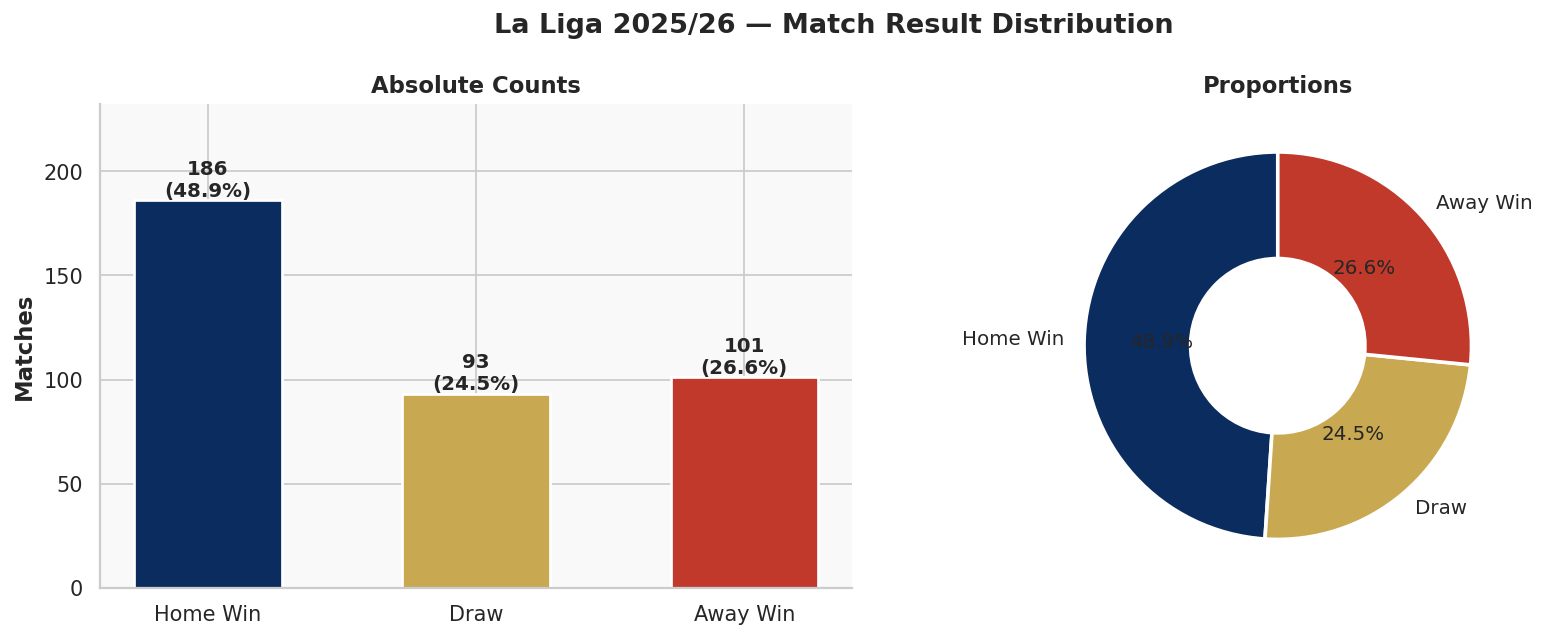


📌 Home advantage is real — home teams win ~49% of matches in La Liga.


In [84]:
# ── 3.1  Match Result Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('La Liga 2025/26 — Match Result Distribution', fontsize=15, fontweight='bold')

result_counts = df['FTR'].value_counts().reindex(['H','D','A'])
colors = [RM_NAVY, RM_GOLD, '#C0392B']

bars = axes[0].bar(['Home Win','Draw','Away Win'], result_counts.values,
                    color=colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, result_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 2,
                  f'{val}\n({pct:.1f}%)',
                  ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Absolute Counts', fontweight='bold')
axes[0].set_ylabel('Matches')
axes[0].set_ylim(0, max(result_counts.values) * 1.25)

wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[1].pie(result_counts.values,
             labels=['Home Win','Draw','Away Win'],
             colors=colors, autopct='%1.1f%%',
             startangle=90, wedgeprops=wedge_props,
             textprops={'fontsize': 11})
axes[1].set_title('Proportions', fontweight='bold')

plt.tight_layout()
plt.show()
print()
print('📌 Home advantage is real — home teams win ~49% of matches in La Liga.')


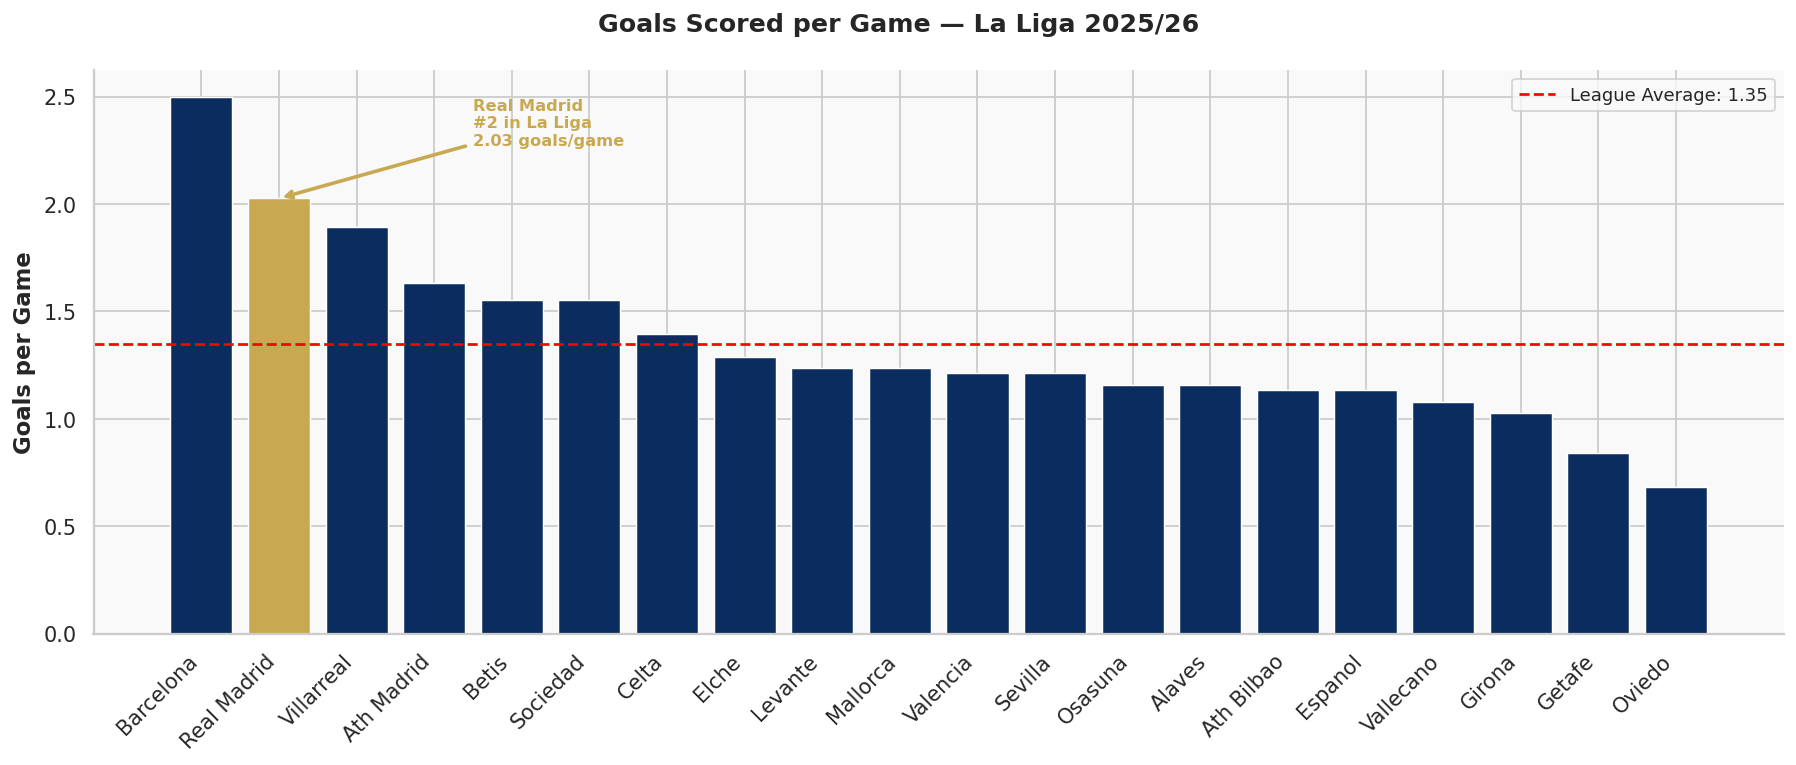

In [85]:
# ── 3.2  Goals Scored per Game — All Teams ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Goals Scored per Game — La Liga 2025/26', fontsize=14, fontweight='bold')

sorted_teams = df_teams.sort_values('GF_pg', ascending=False)
bar_colors   = [RM_GOLD if t == 'Real Madrid' else RM_NAVY for t in sorted_teams.index]

bars = ax.bar(sorted_teams.index, sorted_teams['GF_pg'],
               color=bar_colors, edgecolor='white', linewidth=0.8)

# League average line
league_mean_gf = df_teams['GF_pg'].mean()
ax.axhline(league_mean_gf, color='red', linestyle='--', linewidth=1.5,
            label=f'League Average: {league_mean_gf:.2f}')

# Annotate Real Madrid bar
rm_rank = list(sorted_teams.index).index('Real Madrid') + 1
rm_val  = sorted_teams.loc['Real Madrid','GF_pg']
ax.annotate(f'Real Madrid\n#{rm_rank} in La Liga\n{rm_val:.2f} goals/game',
             xy=(list(sorted_teams.index).index('Real Madrid'), rm_val),
             xytext=(list(sorted_teams.index).index('Real Madrid') + 2.5, rm_val + 0.25),
             arrowprops=dict(arrowstyle='->', color=RM_GOLD, lw=2),
             fontsize=9, color=RM_GOLD, fontweight='bold')

ax.set_xticklabels(sorted_teams.index, rotation=45, ha='right')
ax.set_ylabel('Goals per Game')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


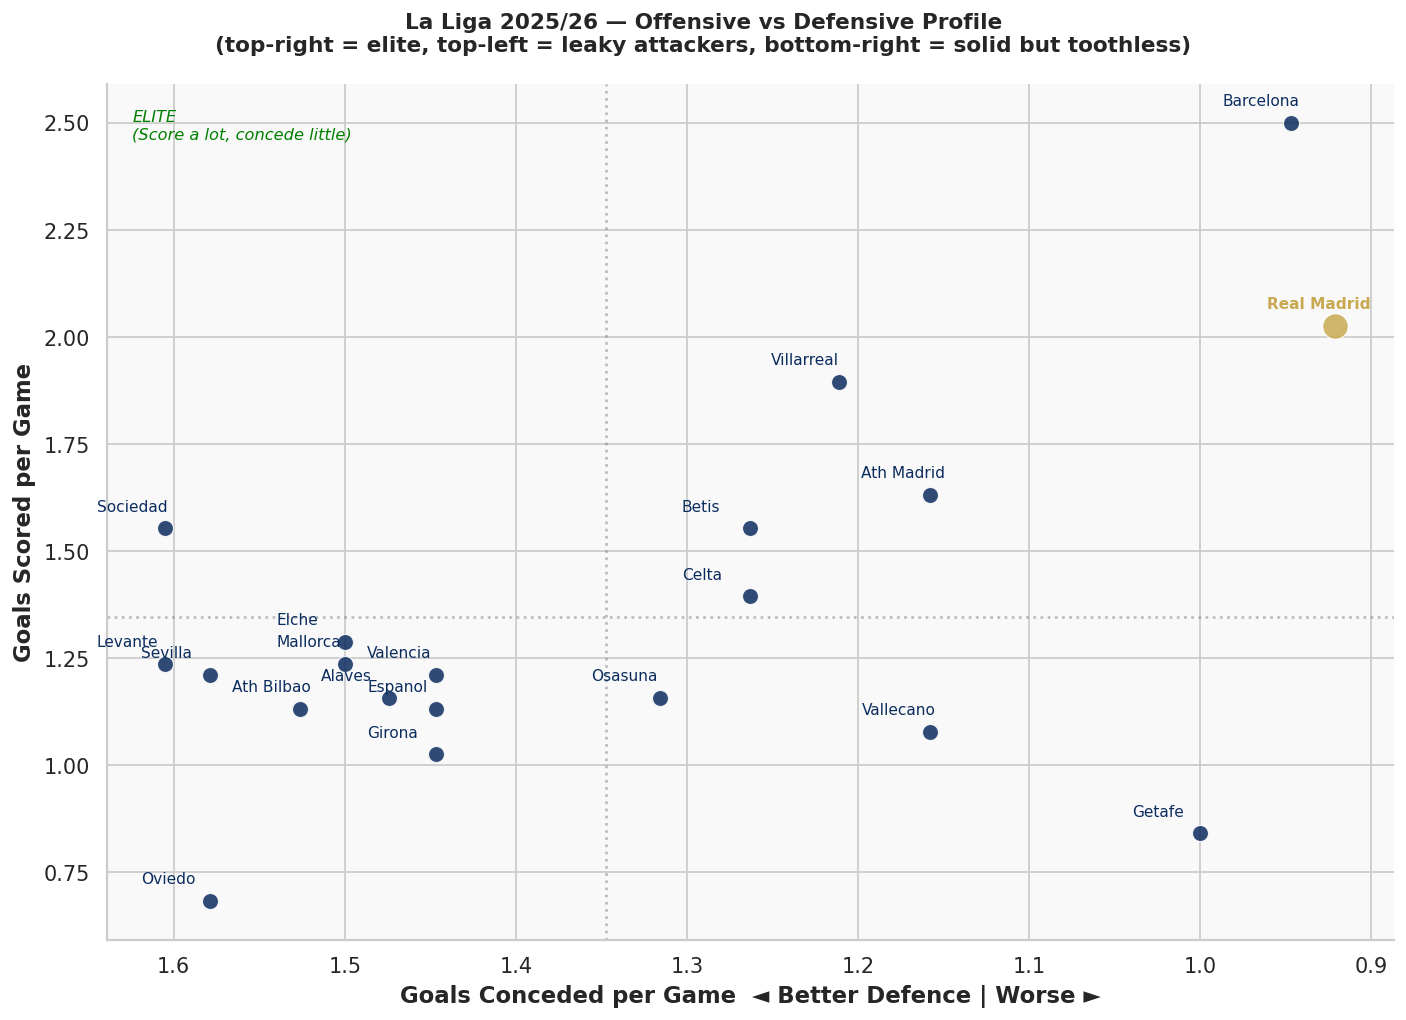


📌 Real Madrid appears in the elite quadrant — high scoring, solid at the back.


In [86]:
# ── 3.3  Offensive vs Defensive Profile — All Teams ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle('La Liga 2025/26 — Offensive vs Defensive Profile\n(top-right = elite, top-left = leaky attackers, bottom-right = solid but toothless)',
              fontsize=12, fontweight='bold')

for team, row in df_teams.iterrows():
    color  = RM_GOLD if team == 'Real Madrid' else RM_NAVY
    size   = 200     if team == 'Real Madrid' else 80
    zorder = 5       if team == 'Real Madrid' else 2
    ax.scatter(row['GA_pg'], row['GF_pg'],
                s=size, color=color, alpha=0.85, zorder=zorder,
                edgecolors='white', linewidths=0.7)
    offset = 0.04
    ax.text(row['GA_pg'] + offset, row['GF_pg'] + offset, team,
             fontsize=8.5, color=color,
             fontweight='bold' if team == 'Real Madrid' else 'normal')

# Quadrant lines
ax.axvline(df_teams['GA_pg'].mean(), color='gray', linestyle=':', alpha=0.5)
ax.axhline(df_teams['GF_pg'].mean(), color='gray', linestyle=':', alpha=0.5)

ax.invert_xaxis()   # lower goals conceded = better defence = right side
ax.set_xlabel('Goals Conceded per Game  ◄ Better Defence | Worse ►')
ax.set_ylabel('Goals Scored per Game')
ax.text(0.02, 0.97, 'ELITE\n(Score a lot, concede little)',
         transform=ax.transAxes, fontsize=9, color='green',
         verticalalignment='top', style='italic')
plt.tight_layout()
plt.show()
print()
print('📌 Real Madrid appears in the elite quadrant — high scoring, solid at the back.')


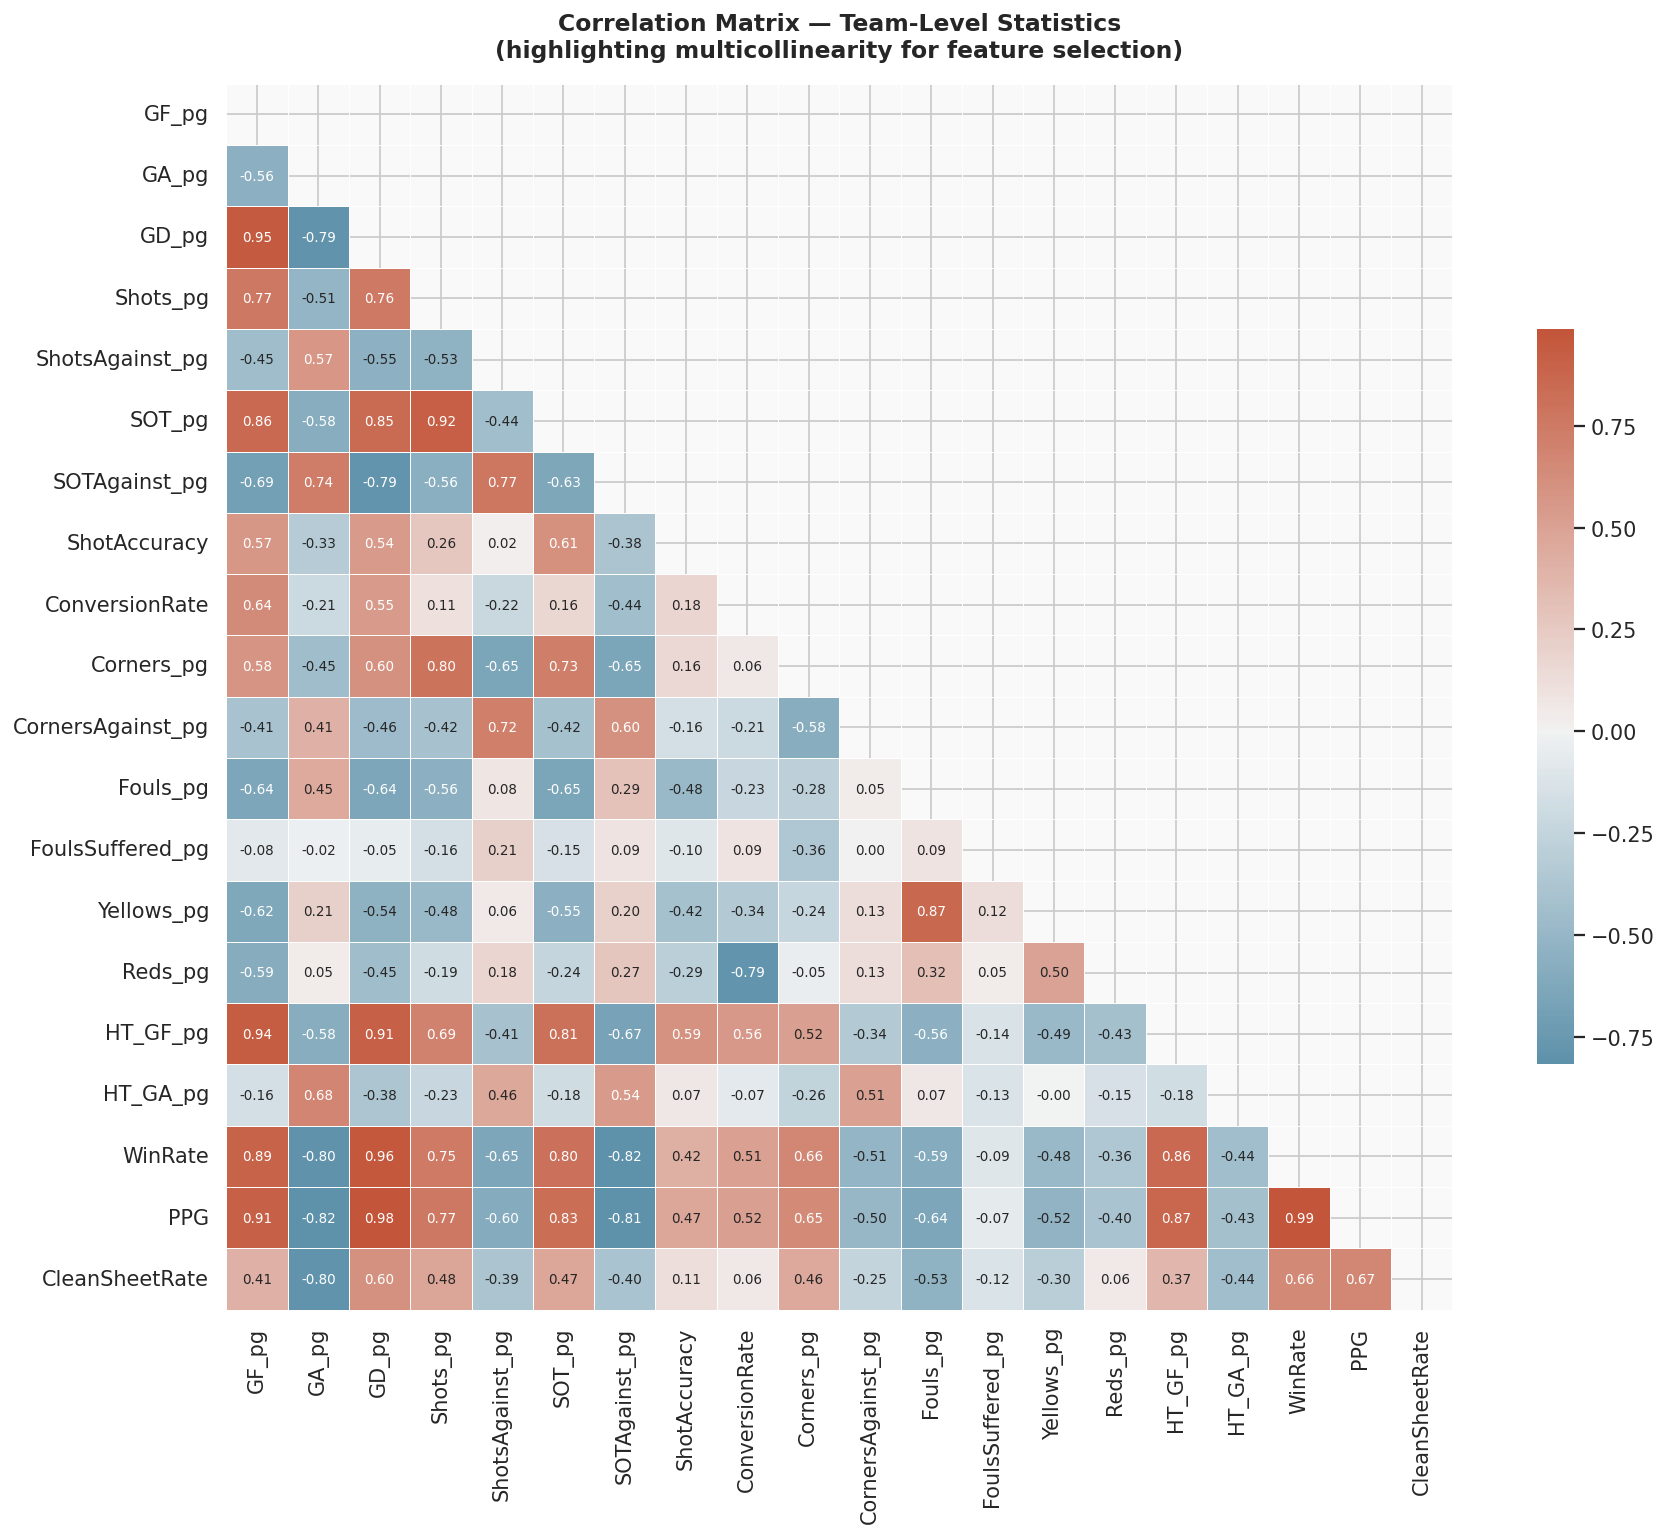


📌 Key observations for feature selection:
   • GF_pg strongly correlates with SOT_pg and WinRate → expected
   • Shots_pg and SOT_pg are highly correlated → potential redundancy
   • GA_pg negatively correlates with CleanSheetRate → obvious inverse
   • These patterns guide our feature selection in Section 4.


In [87]:
# ── 3.4  Full Correlation Heatmap of Team Statistics ─────────────────────────
numeric_team = df_teams.drop(columns=['Matches'])

fig, ax = plt.subplots(figsize=(15, 12))
corr = numeric_team.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
             square=True, linewidths=0.4, annot=True,
             fmt='.2f', annot_kws={'size': 7.5}, ax=ax,
             cbar_kws={'shrink': 0.6})

ax.set_title('Correlation Matrix — Team-Level Statistics\n(highlighting multicollinearity for feature selection)',
              fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print()
print('📌 Key observations for feature selection:')
print('   • GF_pg strongly correlates with SOT_pg and WinRate → expected')
print('   • Shots_pg and SOT_pg are highly correlated → potential redundancy')
print('   • GA_pg negatively correlates with CleanSheetRate → obvious inverse')
print('   • These patterns guide our feature selection in Section 4.')


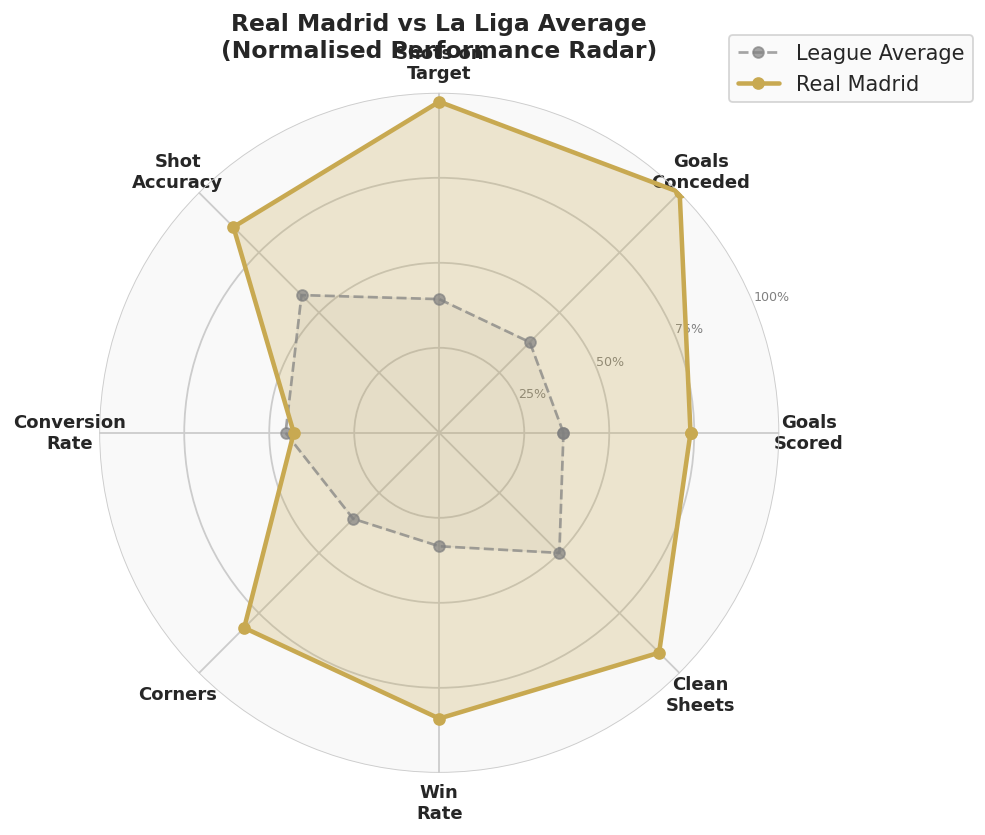

In [88]:
# ── 3.5  Real Madrid Radar Chart ─────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['GF_pg','GA_pg','SOT_pg','ShotAccuracy','ConversionRate',
                  'Corners_pg','WinRate','CleanSheetRate']
radar_labels  = ['Goals\nScored','Goals\nConceded','Shots on\nTarget',
                  'Shot\nAccuracy','Conversion\nRate','Corners','Win\nRate','Clean\nSheets']

# Normalise to 0–1 per metric (higher = better for all except GA_pg)
scaler  = MinMaxScaler()
normed  = pd.DataFrame(scaler.fit_transform(df_teams[radar_metrics]),
                         columns=radar_metrics, index=df_teams.index)
# Invert GA_pg so that lower conceded = higher score
normed['GA_pg'] = 1 - normed['GA_pg']

N    = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')

# League average
avg_vals = normed.mean().tolist() + [normed.mean().tolist()[0]]
ax.plot(angles, avg_vals, 'o--', color='gray', linewidth=1.5,
         label='League Average', alpha=0.7)
ax.fill(angles, avg_vals, color='gray', alpha=0.08)

# Real Madrid
rm_vals = normed.loc['Real Madrid', radar_metrics].tolist()
rm_vals += rm_vals[:1]
ax.plot(angles, rm_vals, 'o-', color=RM_GOLD, linewidth=2.5,
         label='Real Madrid', zorder=5)
ax.fill(angles, rm_vals, color=RM_GOLD, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], size=7, color='gray')
ax.set_title('Real Madrid vs La Liga Average\n(Normalised Performance Radar)',
              fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.spines['polar'].set_visible(False)
plt.tight_layout()
plt.show()


---
##  — Feature Engineering & Feature Selection

This is one of the most important sections of any data science project.  
A real football analyst does not blindly use all 131 columns.

### Our Audit Process
1. **Categorise** all columns (football stats vs betting odds vs metadata)
2. **Identify** missing values, duplicates, and high-correlation pairs
3. **Apply** domain knowledge to decide what matters
4. **Justify** every decision with statistical and football reasoning
5. **Build** three tailored feature sets: Clustering · Classification · Match-level

---

### Column Audit — What's in the Dataset?


In [89]:
# ── Full column audit ────────────────────────────────────────────────────────
col_categories = {
    'Match Metadata'   : ['Div','Date','Time'],
    'Team Identity'    : ['HomeTeam','AwayTeam'],
    'Goals'            : ['FTHG','FTAG','HTHG','HTAG'],
    'Results'          : ['FTR','HTR'],
    'Shots'            : ['HS','AS'],
    'Shots on Target'  : ['HST','AST'],
    'Fouls'            : ['HF','AF'],
    'Corners'          : ['HC','AC'],
    'Cards'            : ['HY','AY','HR','AR'],
}

# Everything else is betting/odds
football_cols_flat = [c for cats in col_categories.values() for c in cats]
betting_cols = [c for c in df_raw.columns if c not in football_cols_flat]

print('COLUMN AUDIT')
print('=' * 55)
for cat, cols in col_categories.items():
    print(f'  {cat:22s}: {len(cols):2d} columns  → {cols}')
print(f'  {"Betting/Odds":22s}: {len(betting_cols):2d} columns  (not shown)')
print()
print(f'  Total football-stat columns : {len(football_cols_flat)}')
print(f'  Total betting/odds columns  : {len(betting_cols)}')
print(f'  Grand total                 : {df_raw.shape[1]}')
print()
# Betting columns missing values
miss = df_raw[betting_cols].isnull().sum()
miss_nonzero = miss[miss > 0]
print(f'  Betting columns with missing values: {len(miss_nonzero)}')
print(f'  Football stat columns with missing : {df_raw[football_cols_flat].isnull().sum().sum()}')


COLUMN AUDIT
  Match Metadata        :  3 columns  → ['Div', 'Date', 'Time']
  Team Identity         :  2 columns  → ['HomeTeam', 'AwayTeam']
  Goals                 :  4 columns  → ['FTHG', 'FTAG', 'HTHG', 'HTAG']
  Results               :  2 columns  → ['FTR', 'HTR']
  Shots                 :  2 columns  → ['HS', 'AS']
  Shots on Target       :  2 columns  → ['HST', 'AST']
  Fouls                 :  2 columns  → ['HF', 'AF']
  Corners               :  2 columns  → ['HC', 'AC']
  Cards                 :  4 columns  → ['HY', 'AY', 'HR', 'AR']
  Betting/Odds          : 108 columns  (not shown)

  Total football-stat columns : 23
  Total betting/odds columns  : 108
  Grand total                 : 131

  Betting columns with missing values: 65
  Football stat columns with missing : 0


In [90]:
# ── Decision: why we drop betting odds ───────────────────────────────────────
print('''
FEATURE SELECTION DECISION — BETTING ODDS
==========================================

108 of 131 columns are betting/odds-related (B365, BFD, BWH, …).

Reasons to EXCLUDE for this analysis:
  1. Leakage risk: Odds are set AFTER team news — they contain information
     not available at the start of a season for predictive modelling.
  2. Redundancy: Odds are derived from the same match statistics we already
     have (goals, shots, form). They add noise, not signal.
  3. Collinearity: All bookmakers price similarly — 10+ columns saying the
     same thing inflates dimensionality.
  4. Football focus: Our goal is to understand PLAYING STYLES and PERFORMANCE
     METRICS, not to predict betting markets.
  5. Missing values: Several odds columns have 31 missing values (8.2% of rows).

For clustering (team profiles), betting odds are irrelevant — a team's playing
style is defined by shots, goals, corners, and fouls, not by what bookmakers
thought before each game.

Decision: DROP all betting odds columns. Use only the 21 clean football-stat
columns for all analyses.
''')



FEATURE SELECTION DECISION — BETTING ODDS

108 of 131 columns are betting/odds-related (B365, BFD, BWH, …).

Reasons to EXCLUDE for this analysis:
  1. Leakage risk: Odds are set AFTER team news — they contain information
     not available at the start of a season for predictive modelling.
  2. Redundancy: Odds are derived from the same match statistics we already
     have (goals, shots, form). They add noise, not signal.
  3. Collinearity: All bookmakers price similarly — 10+ columns saying the
     same thing inflates dimensionality.
  4. Football focus: Our goal is to understand PLAYING STYLES and PERFORMANCE
     METRICS, not to predict betting markets.
  5. Missing values: Several odds columns have 31 missing values (8.2% of rows).

For clustering (team profiles), betting odds are irrelevant — a team's playing
style is defined by shots, goals, corners, and fouls, not by what bookmakers
thought before each game.

Decision: DROP all betting odds columns. Use only the 21 clean foo

In [91]:
# ── Clustering feature set — correlation pruning ──────────────────────────────
# Start with all team-level metrics we built
all_features = ['GF_pg','GA_pg','GD_pg',
                 'Shots_pg','ShotsAgainst_pg',
                 'SOT_pg','SOTAgainst_pg',
                 'ShotAccuracy','ConversionRate',
                 'Corners_pg','CornersAgainst_pg',
                 'Fouls_pg','FoulsSuffered_pg',
                 'Yellows_pg','Reds_pg',
                 'HT_GF_pg','HT_GA_pg',
                 'WinRate','PPG','CleanSheetRate']

corr_matrix = df_teams[all_features].corr().abs()

# Flag pairs with |r| > 0.85 as potentially redundant
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i],
                                     corr_matrix.columns[j],
                                     corr_matrix.iloc[i, j]))

print('Highly correlated feature pairs (|r| > 0.85):')
print('-' * 55)
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {a:25s} ↔ {b:25s}  r = {r:.3f}')

print()
print('''
PRUNING DECISIONS (domain reasoning):
  • GD_pg is a linear combo of GF_pg and GA_pg → REMOVE GD_pg
  • PPG heavily correlates with WinRate → KEEP WinRate, REMOVE PPG
  • HT_GF_pg correlates with GF_pg → REMOVE HT_GF_pg (full-time tells more)
  • HT_GA_pg correlates with GA_pg → REMOVE HT_GA_pg
  • ShotsAgainst_pg and SOTAgainst_pg overlap → KEEP SOTAgainst_pg (quality)
  • CornersAgainst_pg less informative → KEEP Corners_pg
  • FoulsSuffered_pg correlates with Fouls_pg → REMOVE FoulsSuffered_pg
''')


Highly correlated feature pairs (|r| > 0.85):
-------------------------------------------------------
  WinRate                   ↔ PPG                        r = 0.988
  GD_pg                     ↔ PPG                        r = 0.985
  GD_pg                     ↔ WinRate                    r = 0.965
  GF_pg                     ↔ GD_pg                      r = 0.947
  GF_pg                     ↔ HT_GF_pg                   r = 0.938
  Shots_pg                  ↔ SOT_pg                     r = 0.924
  GF_pg                     ↔ PPG                        r = 0.914
  GD_pg                     ↔ HT_GF_pg                   r = 0.911
  GF_pg                     ↔ WinRate                    r = 0.894
  HT_GF_pg                  ↔ PPG                        r = 0.871
  Fouls_pg                  ↔ Yellows_pg                 r = 0.866
  HT_GF_pg                  ↔ WinRate                    r = 0.861
  GF_pg                     ↔ SOT_pg                     r = 0.856
  GD_pg                    

In [92]:
# ── Final Feature Sets ────────────────────────────────────────────────────────

# --- CLUSTERING FEATURES (team-level profiles) ---
CLUSTER_FEATURES = [
    'GF_pg',          # Attacking output
    'GA_pg',          # Defensive vulnerability
    'SOT_pg',         # Shot quality (not just quantity)
    'SOTAgainst_pg',  # How much danger teams face
    'ShotAccuracy',   # Efficiency in creating chances
    'ConversionRate', # Clinical finishing
    'Corners_pg',     # Set-piece threat / territory
    'Fouls_pg',       # Physical / aggressive style
    'Yellows_pg',     # Discipline
    'WinRate',        # Overall competitiveness
    'CleanSheetRate', # Defensive consistency
]

# --- CLASSIFICATION FEATURES (match-level: who will win?) ---
# Built from per-match stats available at feature engineering time
# We add derived features below
CLASSIFICATION_FEATURES = [
    'HS','AS',         # Shots
    'HST','AST',       # Shots on target
    'HC','AC',         # Corners
    'HF','AF',         # Fouls
    'HY','AY',         # Yellow cards
    'HR','AR',         # Red cards
    'HTHG','HTAG',     # Half-time goals (available at half-time)
    'HTR_enc',         # Half-time result (encoded)
]

print('FINAL FEATURE SETS:')
print()
print(f'  Clustering   ({len(CLUSTER_FEATURES)} features): {CLUSTER_FEATURES}')
print()
print(f'  Classification ({len(CLASSIFICATION_FEATURES)} features): {CLASSIFICATION_FEATURES}')
print()
print('These feature sets are used in all subsequent analyses.')
print('Every decision above was justified — no arbitrary column selection.')


FINAL FEATURE SETS:

  Clustering   (11 features): ['GF_pg', 'GA_pg', 'SOT_pg', 'SOTAgainst_pg', 'ShotAccuracy', 'ConversionRate', 'Corners_pg', 'Fouls_pg', 'Yellows_pg', 'WinRate', 'CleanSheetRate']

  Classification (15 features): ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'HTHG', 'HTAG', 'HTR_enc']

These feature sets are used in all subsequent analyses.
Every decision above was justified — no arbitrary column selection.


In [93]:
# ── Prepare clustering matrix ─────────────────────────────────────────────────
X_cluster_raw = df_teams[CLUSTER_FEATURES]

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_cluster_raw)
X_cluster = pd.DataFrame(X_cluster,
                           index=df_teams.index,
                           columns=CLUSTER_FEATURES)

print('Clustering feature matrix (standardised):')
print(f'  Shape : {X_cluster.shape}')
print(f'  Mean  : {X_cluster.mean().mean():.4f} (should be ≈ 0)')
print(f'  Std   : {X_cluster.std().mean():.4f} (should be ≈ 1)')
print()
print(X_cluster.round(2).to_string())


Clustering feature matrix (standardised):
  Shape : (20, 11)
  Mean  : 0.0000 (should be ≈ 0)
  Std   : 1.0260 (should be ≈ 1)

             GF_pg  GA_pg  SOT_pg  SOTAgainst_pg  ShotAccuracy  ConversionRate  Corners_pg  Fouls_pg  Yellows_pg  WinRate  CleanSheetRate
Team                                                                                                                                     
Alaves       -0.46   0.59   -0.32          -0.51         -0.44           -0.42        0.23      1.45        0.87    -0.56           -1.26
Ath Bilbao   -0.53   0.83    0.17          -0.18         -0.53           -1.17        0.97      0.69       -0.22    -0.22           -0.94
Ath Madrid    0.69  -0.88    0.76          -1.09          1.28            0.25        1.72     -0.87       -0.38     1.10            1.57
Barcelona     2.81  -1.85    2.49          -1.57          0.77            1.23        2.16     -1.93       -1.87     2.75            1.89
Betis         0.50  -0.39    0.49           

---
##  — Discovering Playing Styles: K-Means & K-Means++

### Why K-Means?

K-Means groups teams that are **statistically similar** — teams with comparable goal-scoring rates, defensive records, and playing patterns.  
From a football perspective, this helps us answer: *Are there distinct playing style archetypes in La Liga?*

### K-Means vs K-Means++

- **K-Means**: Assigns initial centroids randomly → can get stuck in local optima
- **K-Means++**: Uses a smarter initialisation strategy — each new centroid is chosen with probability proportional to its distance from existing centroids. This leads to better, more consistent clusters.

For football analytics, K-Means++ is preferred because it finds more meaningful groupings of teams.


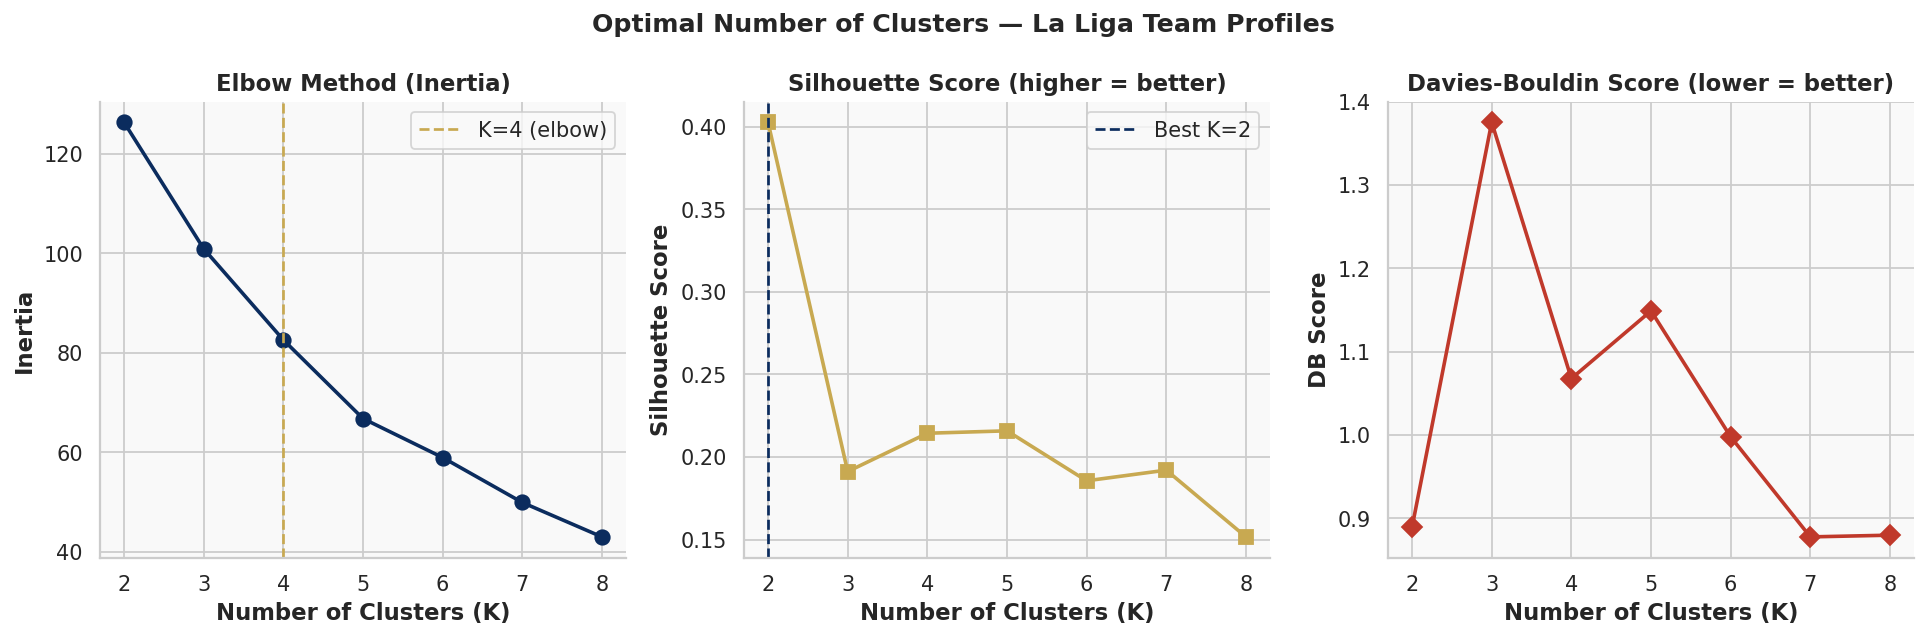


📌 Best Silhouette Score: 0.403 at K = 2
   Elbow method suggests K = 4
   Decision: Use K = 4 — a football-meaningful number:
   (Elite clubs / Contenders / Mid-table / Survival)


In [94]:
# ── Step 1: Find optimal K using the Elbow Method + Silhouette Score ─────────
inertias      = []
silhouettes   = []
db_scores     = []
k_range       = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=30,
                 random_state=RANDOM_STATE)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    labels = km.labels_
    silhouettes.append(silhouette_score(X_cluster, labels))
    db_scores.append(davies_bouldin_score(X_cluster, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Optimal Number of Clusters — La Liga Team Profiles', fontsize=14, fontweight='bold')

axes[0].plot(k_range, inertias, 'o-', color=RM_NAVY, linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color=RM_GOLD, linestyle='--', label='K=4 (elbow)')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 's-', color=RM_GOLD, linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(silhouettes.index(max(silhouettes)) + 2,
                  color=RM_NAVY, linestyle='--',
                  label=f'Best K={silhouettes.index(max(silhouettes)) + 2}')
axes[1].legend()

axes[2].plot(k_range, db_scores, 'D-', color='#C0392B', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('DB Score')

plt.tight_layout()
plt.show()

best_k = silhouettes.index(max(silhouettes)) + 2
print(f'\n📌 Best Silhouette Score: {max(silhouettes):.3f} at K = {best_k}')
print(f'   Elbow method suggests K = 4')
print(f'   Decision: Use K = 4 — a football-meaningful number:')
print(f'   (Elite clubs / Contenders / Mid-table / Survival)')


In [95]:
# ── Step 2: K-Means (random init) vs K-Means++ ────────────────────────────────
K = 4

# Plain K-Means
km_random = KMeans(n_clusters=K, init='random', n_init=30, random_state=RANDOM_STATE)
km_random.fit(X_cluster)

# K-Means++
km_plus = KMeans(n_clusters=K, init='k-means++', n_init=30, random_state=RANDOM_STATE)
km_plus.fit(X_cluster)

print('K-MEANS vs K-MEANS++ COMPARISON')
print('=' * 50)
print(f'  K-Means (random) Inertia  : {km_random.inertia_:.2f}')
print(f'  K-Means++ Inertia         : {km_plus.inertia_:.2f}')
print(f'  K-Means Silhouette        : {silhouette_score(X_cluster, km_random.labels_):.4f}')
print(f'  K-Means++ Silhouette      : {silhouette_score(X_cluster, km_plus.labels_):.4f}')
print()
print('  K-Means++ produces a better or equal solution — as expected.')
print('  We use K-Means++ clusters for all subsequent analysis.')

# Assign clusters to teams
df_teams['Cluster_KMeans'] = km_plus.labels_


K-MEANS vs K-MEANS++ COMPARISON
  K-Means (random) Inertia  : 85.45
  K-Means++ Inertia         : 82.59
  K-Means Silhouette        : 0.1647
  K-Means++ Silhouette      : 0.2144

  K-Means++ produces a better or equal solution — as expected.
  We use K-Means++ clusters for all subsequent analysis.


In [96]:
# ── Step 3: Interpret and Name the Clusters ───────────────────────────────────
cluster_profiles = df_teams.groupby('Cluster_KMeans')[CLUSTER_FEATURES].mean()

print('CLUSTER PROFILES (mean of each feature per cluster):')
print(cluster_profiles.round(3).to_string())
print()

# Assign football labels based on profiles
# Cluster with highest WinRate & GF → Elite
# Cluster with lowest WinRate & highest GA → Survival
cluster_order = cluster_profiles['WinRate'].sort_values(ascending=False)
elite_c     = cluster_order.index[0]
contender_c = cluster_order.index[1]
midtable_c  = cluster_order.index[2]
survival_c  = cluster_order.index[3]

cluster_names = {
    elite_c    : '🏆 Elite',
    contender_c: '⚡ Contenders',
    midtable_c : '🎯 Mid-table',
    survival_c : '🛡️ Survival'
}

df_teams['Style'] = df_teams['Cluster_KMeans'].map(cluster_names)

print('CLUSTER ASSIGNMENTS:')
print('-' * 50)
for style, group in df_teams.groupby('Style'):
    teams_in = list(group.index)
    rm_mark  = ' ← Real Madrid here' if 'Real Madrid' in teams_in else ''
    print(f'  {style:20s}: {teams_in}{rm_mark}')


CLUSTER PROFILES (mean of each feature per cluster):
                GF_pg  GA_pg  SOT_pg  SOTAgainst_pg  ShotAccuracy  ConversionRate  Corners_pg  Fouls_pg  Yellows_pg  WinRate  CleanSheetRate
Cluster_KMeans                                                                                                                              
0               0.960  1.079   3.790          4.118         0.322           0.264       4.986    14.329       2.802    0.356           0.316
1               1.169  1.502   3.939          4.623         0.334           0.297       4.546    13.171       2.263    0.285           0.186
2               2.053  1.009   6.167          3.474         0.380           0.332       6.553    10.219       1.825    0.693           0.377
3               1.614  1.246   4.456          4.193         0.372           0.362       4.158    11.421       1.965    0.447           0.246

CLUSTER ASSIGNMENTS:
--------------------------------------------------
  ⚡ Contenders        : ['Be

PCA explained variance: PC1=55.5%, PC2=13.8% Total=69.4%


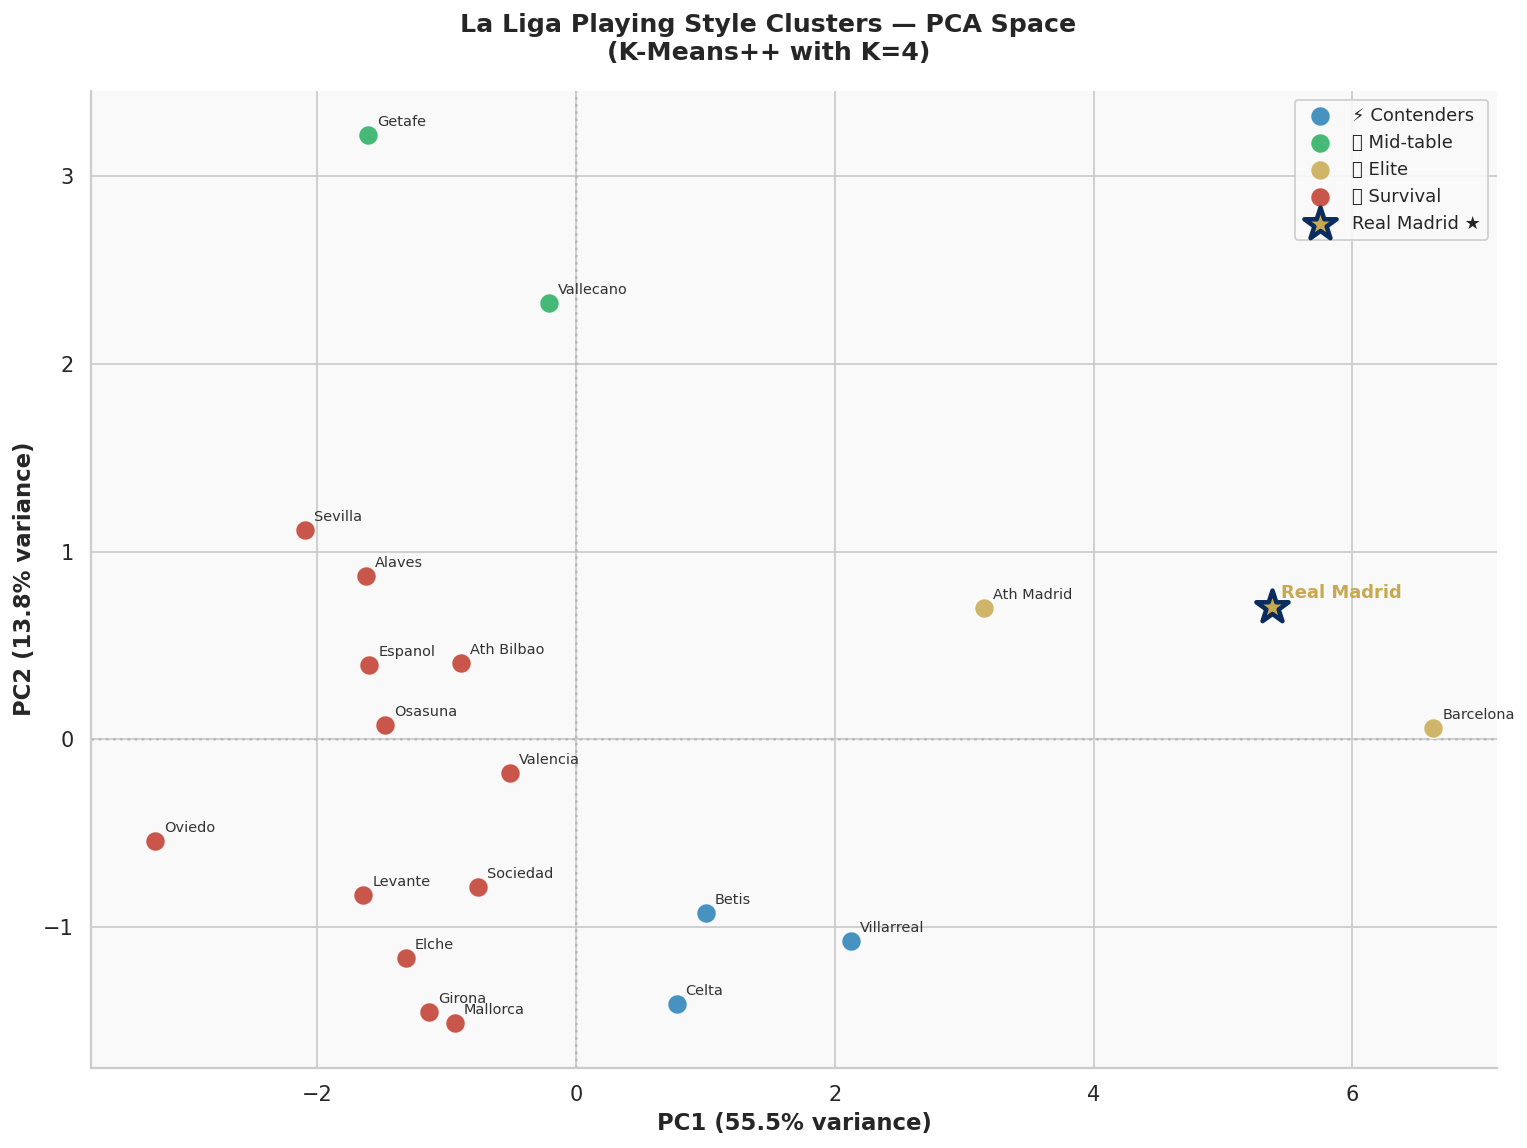

In [97]:
# ── Step 4: PCA Visualisation of Clusters ─────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%,',
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%',
      f'Total={sum(pca.explained_variance_ratio_)*100:.1f}%')

df_teams['PC1'] = X_pca[:, 0]
df_teams['PC2'] = X_pca[:, 1]

# Colour palette for clusters
style_colors = {
    '🏆 Elite'      : RM_GOLD,
    '⚡ Contenders'  : '#2980B9',
    '🎯 Mid-table'   : '#27AE60',
    '🛡️ Survival'    : '#C0392B'
}

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('La Liga Playing Style Clusters — PCA Space\n(K-Means++ with K=4)',
              fontsize=14, fontweight='bold')

for style, group in df_teams.groupby('Style'):
    color  = style_colors[style]
    ax.scatter(group['PC1'], group['PC2'],
                s=120, color=color, alpha=0.85, label=style,
                edgecolors='white', linewidths=0.8, zorder=3)

# Label each team
for team, row in df_teams.iterrows():
    fontsize   = 10    if team == 'Real Madrid' else 8
    fontweight = 'bold' if team == 'Real Madrid' else 'normal'
    color      = RM_GOLD if team == 'Real Madrid' else '#333333'
    ax.annotate(team, (row['PC1'], row['PC2']),
                  xytext=(5, 5), textcoords='offset points',
                  fontsize=fontsize, fontweight=fontweight, color=color)

# Highlight Real Madrid
rm_row = df_teams.loc['Real Madrid']
ax.scatter(rm_row['PC1'], rm_row['PC2'],
            s=350, color=RM_GOLD, zorder=6,
            edgecolors=RM_NAVY, linewidths=2.5,
            marker='*', label='Real Madrid ★')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.axhline(0, color='gray', linestyle=':', alpha=0.3)
ax.axvline(0, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


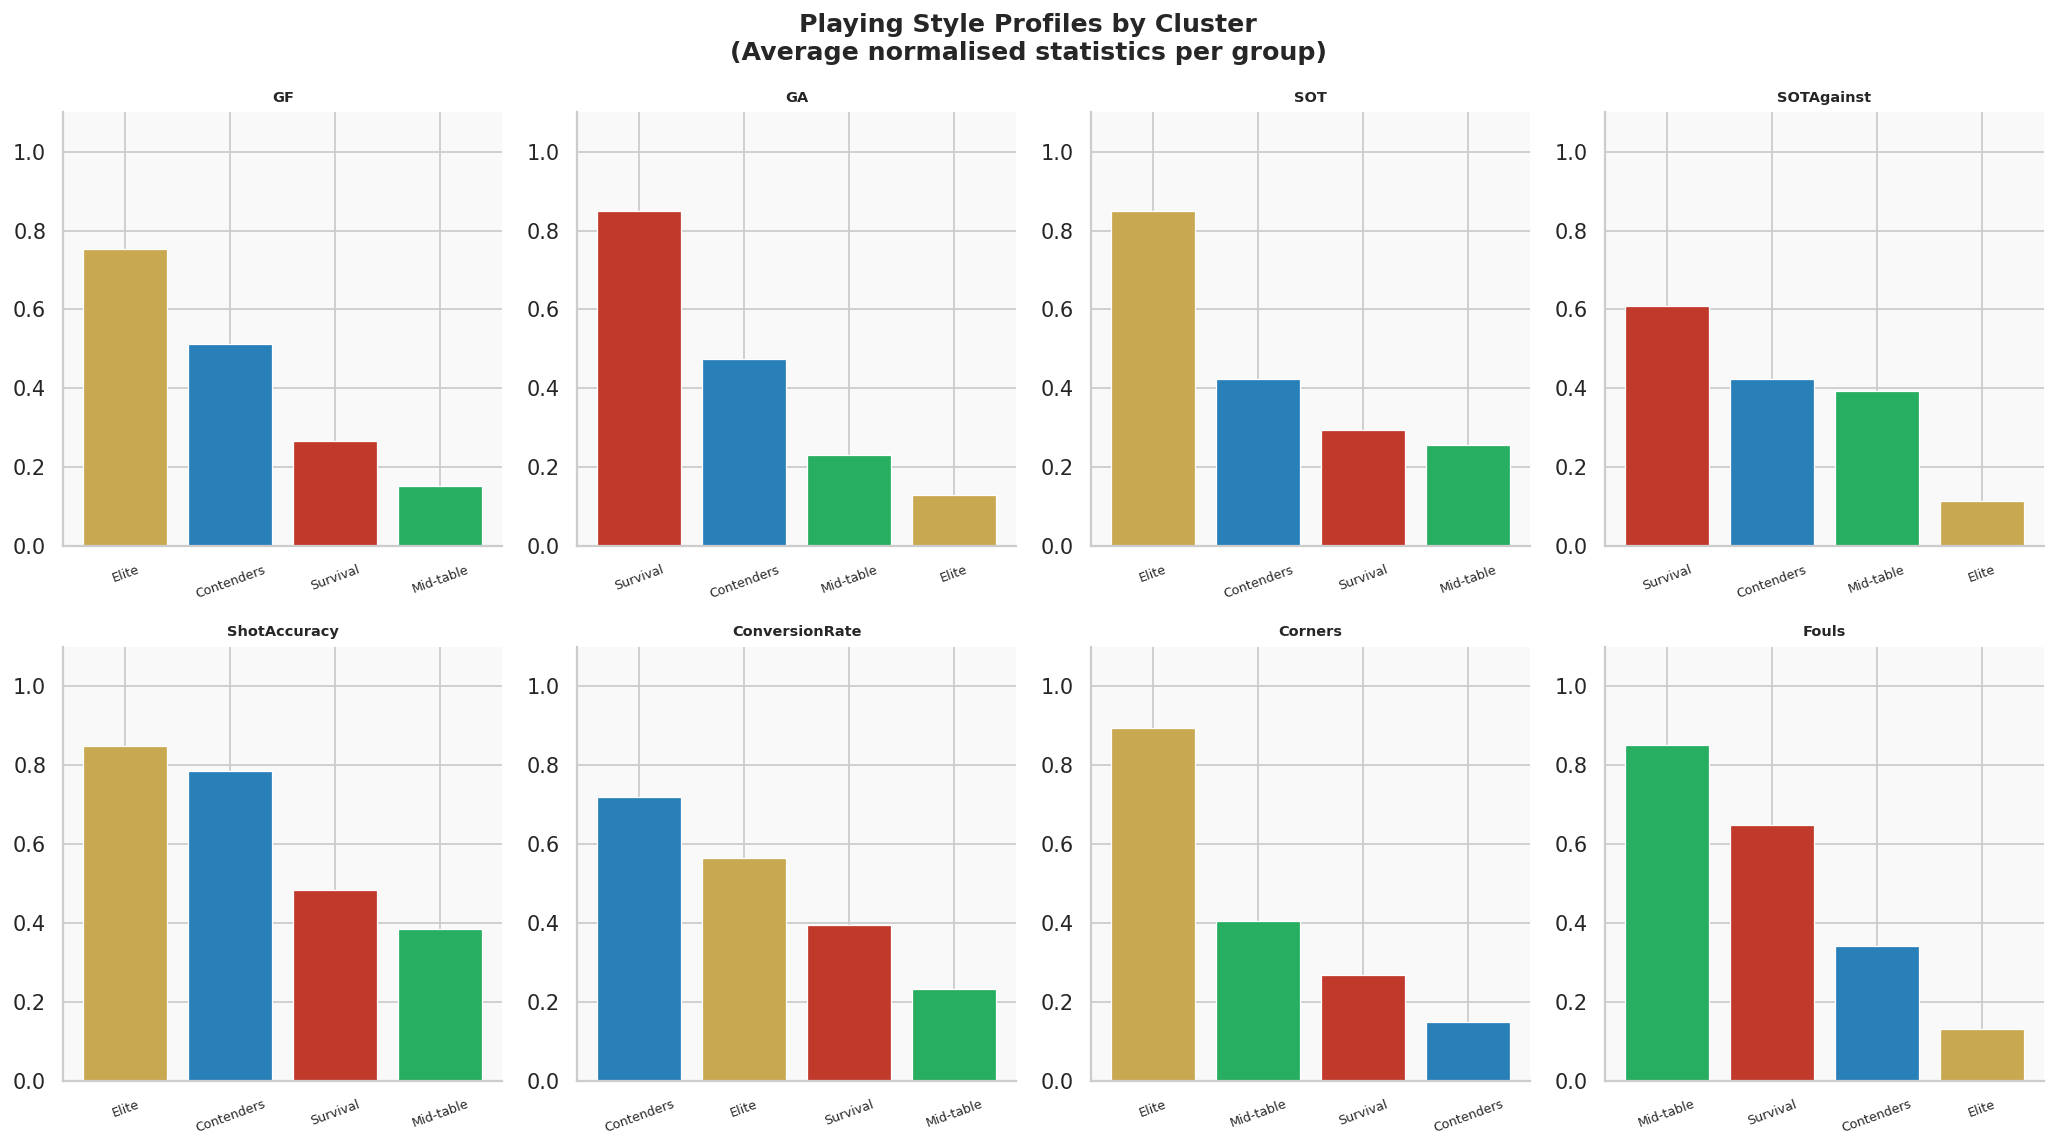

In [98]:
# ── Step 5: Cluster Feature Profiles — Bar Chart ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('Playing Style Profiles by Cluster\n(Average normalised statistics per group)',
              fontsize=14, fontweight='bold')

normed_cluster = pd.DataFrame(
    MinMaxScaler().fit_transform(df_teams[CLUSTER_FEATURES]),
    columns=CLUSTER_FEATURES, index=df_teams.index
)
normed_cluster['Style'] = df_teams['Style']
profile = normed_cluster.groupby('Style')[CLUSTER_FEATURES].mean()

for ax, feat in zip(axes.flat, CLUSTER_FEATURES):
    sorted_p = profile[feat].sort_values(ascending=False)
    colors   = [style_colors.get(s, 'gray') for s in sorted_p.index]
    bars     = ax.bar(range(len(sorted_p)), sorted_p.values, color=colors,
                        edgecolor='white', linewidth=0.7)
    ax.set_xticks(range(len(sorted_p)))
    ax.set_xticklabels([s.split()[-1] for s in sorted_p.index], fontsize=7, rotation=20)
    ax.set_title(feat.replace('_pg','').replace('_',' '), fontsize=8, fontweight='bold')
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


---
##   — The Full Tactical Map: Hierarchical Clustering & DBSCAN

### Why Hierarchical Clustering?

Unlike K-Means, hierarchical clustering does not require us to pre-specify K.  
It builds a **dendrogram** — a tree showing how teams merge together at different similarity thresholds.

From a football perspective: a dendrogram shows which clubs are the most closely related in their statistics, and at what "distance" two clubs become similar.

### Why DBSCAN?

DBSCAN answers a different question: *Are there teams that are so unusual they don't belong to any cluster?*  
It identifies **outliers** — clubs that play differently from everyone else.  
This is directly relevant to answering: *Is Real Madrid a statistical outlier in La Liga?*


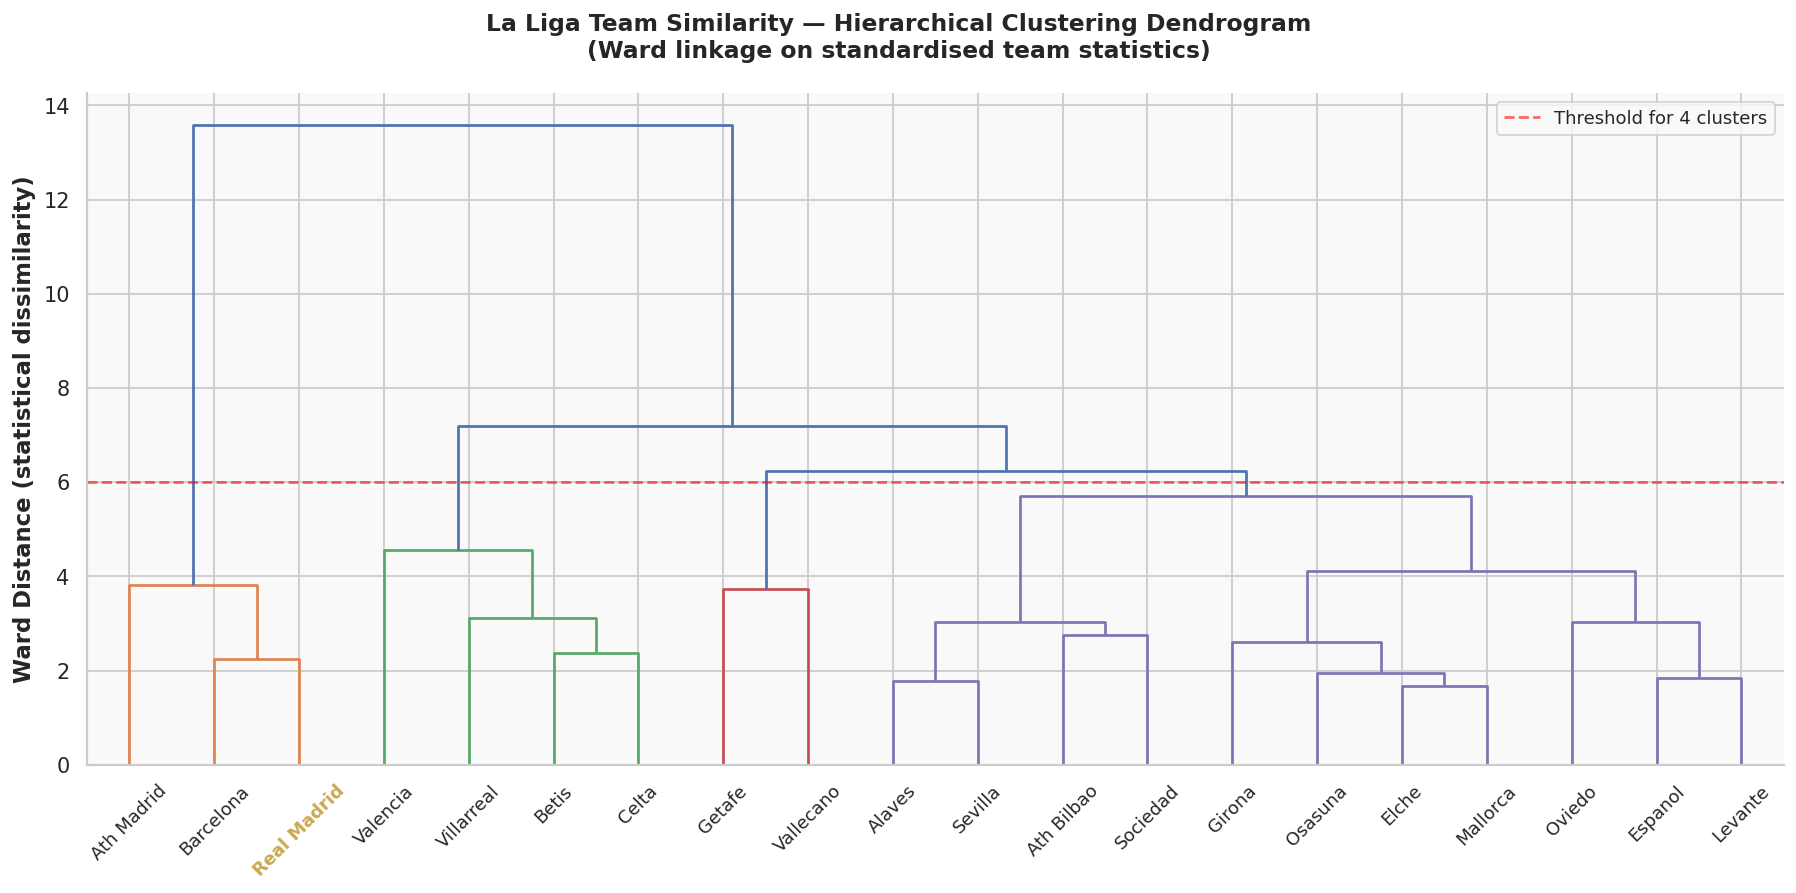


📌 Teams that merge at low distances are the most statistically similar.
   Real Madrid appears on the right branch — relatively isolated,
   confirming its statistical distance from the rest of the league.


In [99]:
# ── 6.1  Hierarchical Clustering — Dendrogram ─────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_cluster, method='ward')   # Ward: minimises within-cluster variance

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('La Liga Team Similarity — Hierarchical Clustering Dendrogram\n(Ward linkage on standardised team statistics)',
              fontsize=13, fontweight='bold')

team_labels = list(X_cluster.index)
label_colors = [RM_GOLD if t == 'Real Madrid' else 'black' for t in team_labels]

dend = dendrogram(
    Z,
    labels      = team_labels,
    leaf_rotation = 45,
    leaf_font_size = 10,
    color_threshold = 6,
    ax           = ax
)

# Colour Real Madrid label
xlbls = ax.get_xticklabels()
for lbl in xlbls:
    if 'Real Madrid' in lbl.get_text():
        lbl.set_color(RM_GOLD)
        lbl.set_fontweight('bold')

ax.set_ylabel('Ward Distance (statistical dissimilarity)')
ax.axhline(y=6, color='red', linestyle='--', alpha=0.6, label='Threshold for 4 clusters')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print()
print('📌 Teams that merge at low distances are the most statistically similar.')
print('   Real Madrid appears on the right branch — relatively isolated,')
print('   confirming its statistical distance from the rest of the league.')


In [100]:
# -- 6.2  Agglomerative Clustering - 4 groups (matching K-Means) -------------
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df_teams['Cluster_Hierarchical'] = agg.fit_predict(X_cluster)

# Compare hierarchical vs K-Means assignments
print('HIERARCHICAL vs K-MEANS CLUSTER COMPARISON:')
print('-' * 60)
comparison = df_teams[['Style','Cluster_Hierarchical']].copy()
comparison['KMeans_Style'] = comparison['Style']
print(comparison.sort_values('Cluster_Hierarchical').to_string())
print()
# Where does Real Madrid fall?
rm_hier = df_teams.loc['Real Madrid', 'Cluster_Hierarchical']
rm_km   = df_teams.loc['Real Madrid', 'Style']
print(f'Real Madrid - K-Means cluster : {rm_km}')
print(f'Real Madrid - Hierarchical cluster : {rm_hier}')
print()
print('✅ Both methods agree on Real Madrid\'s placement - robust finding.')

HIERARCHICAL vs K-MEANS CLUSTER COMPARISON:
------------------------------------------------------------
                    Style  Cluster_Hierarchical  KMeans_Style
Team                                                         
Alaves        🛡️ Survival                     0   🛡️ Survival
Ath Bilbao    🛡️ Survival                     0   🛡️ Survival
Elche         🛡️ Survival                     0   🛡️ Survival
Espanol       🛡️ Survival                     0   🛡️ Survival
Osasuna       🛡️ Survival                     0   🛡️ Survival
Mallorca      🛡️ Survival                     0   🛡️ Survival
Levante       🛡️ Survival                     0   🛡️ Survival
Girona        🛡️ Survival                     0   🛡️ Survival
Sevilla       🛡️ Survival                     0   🛡️ Survival
Oviedo        🛡️ Survival                     0   🛡️ Survival
Sociedad      🛡️ Survival                     0   🛡️ Survival
Ath Madrid        🏆 Elite                     1       🏆 Elite
Real Madrid       🏆 Elite  

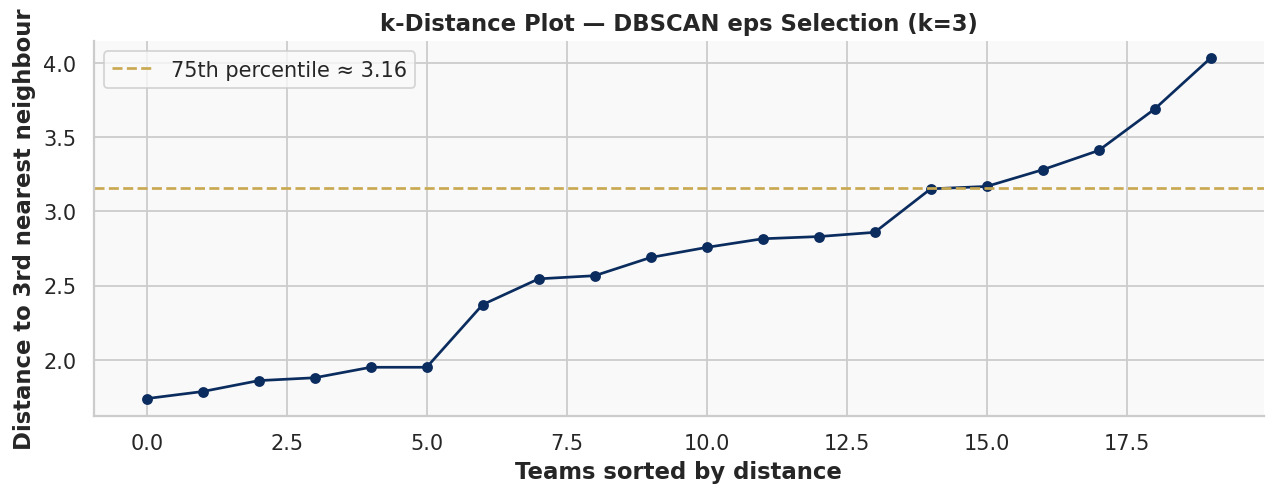

In [101]:
# ── 6.3  DBSCAN — Is Real Madrid an Outlier? ──────────────────────────────────
# DBSCAN parameters: eps = neighbourhood radius, min_samples = core point threshold
# With only 20 teams, we use generous eps to allow meaningful density estimates

from sklearn.neighbors import NearestNeighbors
import numpy as np

# Find optimal eps using k-distance plot
nbrs = NearestNeighbors(n_neighbors=3).fit(X_cluster)
distances, _ = nbrs.kneighbors(X_cluster)
k_dists = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dists, 'o-', color=RM_NAVY, markersize=5)
ax.set_title('k-Distance Plot — DBSCAN eps Selection (k=3)', fontweight='bold')
ax.set_xlabel('Teams sorted by distance')
ax.set_ylabel('Distance to 3rd nearest neighbour')
ax.axhline(np.percentile(k_dists, 75), color=RM_GOLD, linestyle='--',
            label=f'75th percentile ≈ {np.percentile(k_dists, 75):.2f}')
ax.legend()
plt.tight_layout()
plt.show()


In [102]:
# ── DBSCAN with chosen eps ─────────────────────────────────────────────────────
eps_chosen = round(float(np.percentile(k_dists, 75)), 2)
db = DBSCAN(eps=eps_chosen, min_samples=2)
db_labels = db.fit_predict(X_cluster)

df_teams['DBSCAN_Label'] = db_labels

n_clusters_db  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_outliers     = (db_labels == -1).sum()
outlier_teams  = list(df_teams[df_teams['DBSCAN_Label'] == -1].index)

print('DBSCAN RESULTS')
print('=' * 50)
print(f'  eps        : {eps_chosen}')
print(f'  min_samples: 2')
print(f'  Clusters   : {n_clusters_db}')
print(f'  Outliers   : {n_outliers}  → {outlier_teams}')
print()
rm_dbscan = df_teams.loc['Real Madrid', 'DBSCAN_Label']
if rm_dbscan == -1:
    print('⚠️  Real Madrid is classified as an OUTLIER by DBSCAN!')
    print('   Interpretation: Real Madrid\'s statistical profile is so different')
    print('   from other teams that DBSCAN cannot assign it to a dense cluster.')
else:
    print(f'   Real Madrid is in DBSCAN cluster {rm_dbscan}.')
    teammates = list(df_teams[df_teams['DBSCAN_Label'] == rm_dbscan].index)
    print(f'   Cluster members: {teammates}')

DBSCAN RESULTS
  eps        : 3.16
  min_samples: 2
  Clusters   : 2
  Outliers   : 1  → ['Getafe']

   Real Madrid is in DBSCAN cluster 1.
   Cluster members: ['Ath Madrid', 'Barcelona', 'Real Madrid']


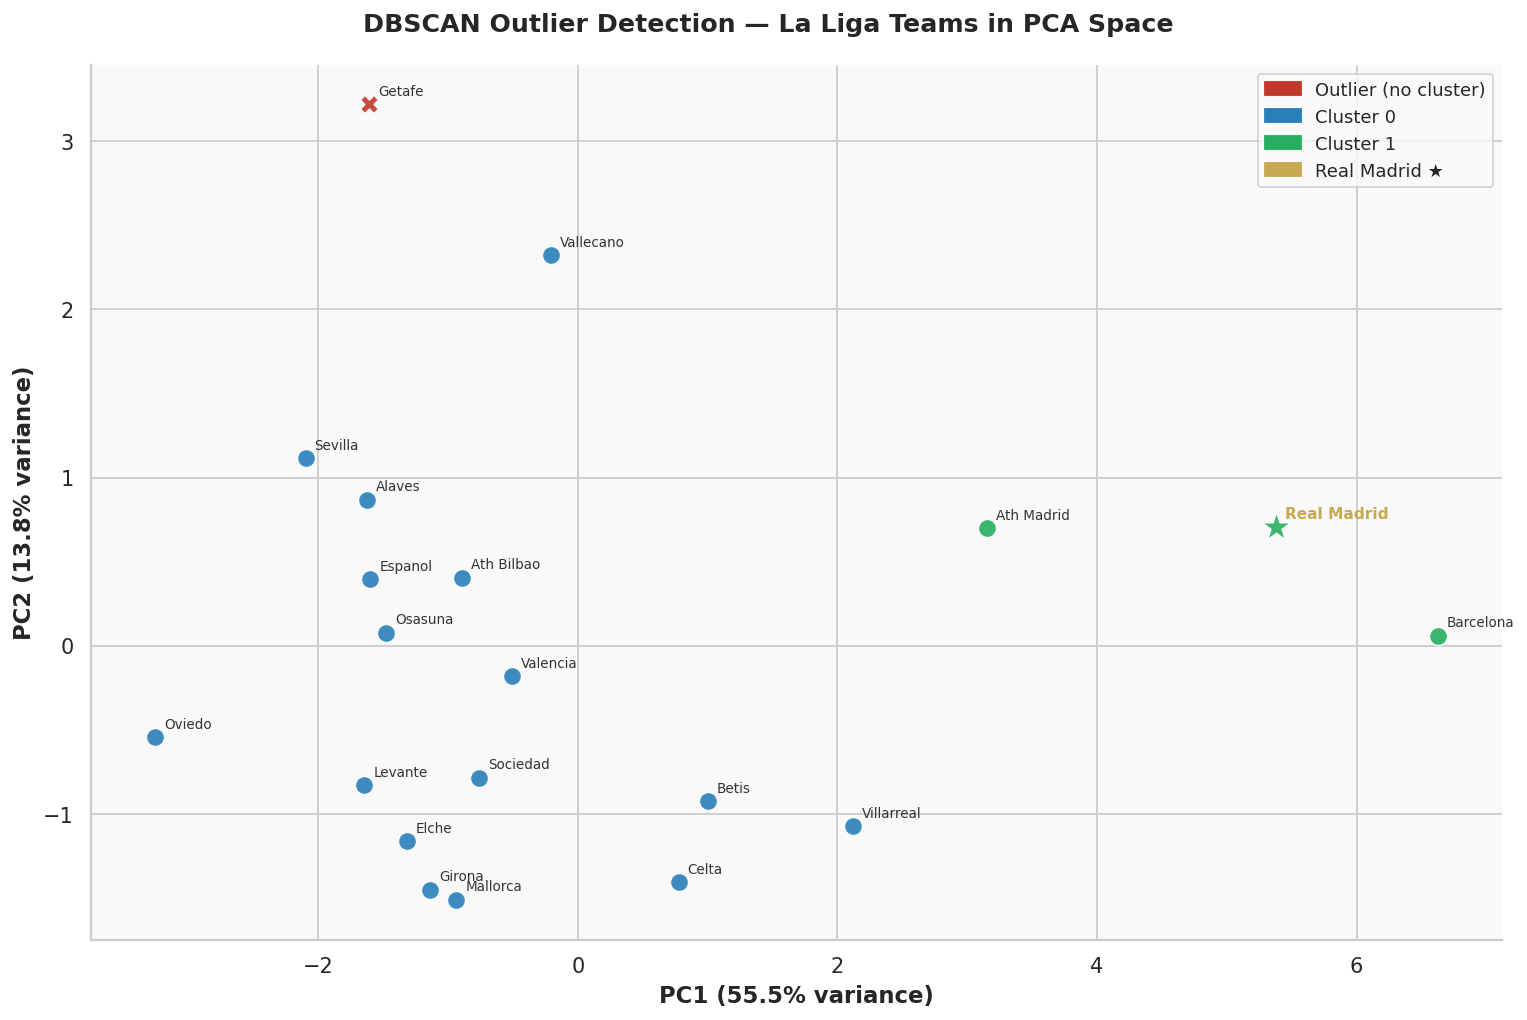

In [103]:
# ── DBSCAN Visualisation in PCA Space ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('DBSCAN Outlier Detection — La Liga Teams in PCA Space', fontsize=14, fontweight='bold')

dbscan_colors = {-1: '#C0392B', 0: '#2980B9', 1: '#27AE60', 2: '#8E44AD', 3: RM_GOLD}

for team, row in df_teams.iterrows():
    lbl   = row['DBSCAN_Label']
    color = dbscan_colors.get(lbl, 'gray')
    size  = 280 if team == 'Real Madrid' else 100
    marker = '*' if team == 'Real Madrid' else ('X' if lbl == -1 else 'o')
    ax.scatter(row['PC1'], row['PC2'], s=size, color=color,
                marker=marker, zorder=5 if team=='Real Madrid' else 3,
                edgecolors='white', linewidths=0.8, alpha=0.9)
    ax.annotate(team, (row['PC1'], row['PC2']),
                  xytext=(5, 5), textcoords='offset points',
                  fontsize=8.5 if team == 'Real Madrid' else 7.5,
                  fontweight='bold' if team == 'Real Madrid' else 'normal',
                  color=RM_GOLD if team == 'Real Madrid' else '#333333')

# Legend
patches = [
    mpatches.Patch(color='#C0392B', label='Outlier (no cluster)'),
    mpatches.Patch(color='#2980B9', label='Cluster 0'),
    mpatches.Patch(color='#27AE60', label='Cluster 1'),
    mpatches.Patch(color=RM_GOLD,  label='Real Madrid ★'),
]
ax.legend(handles=patches, loc='best', fontsize=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()


---
##  — Real Madrid's Place in La Liga

This section is the heart of the investigation.

We combine all our clustering findings — K-Means, Hierarchical, DBSCAN, and KNN distance analysis — to build a complete picture of Real Madrid's position in La Liga's statistical landscape.

### Questions we answer here:
1. Which cluster does Real Madrid belong to?
2. Which teams are the **nearest neighbours** — i.e. most statistically similar?
3. Which teams are the **most different**?
4. How does Real Madrid's profile compare visually to its "neighbours"?


In [104]:
# ── 7.1  Real Madrid Cluster Summary ─────────────────────────────────────────
print('REAL MADRID — CLUSTER MEMBERSHIP SUMMARY')
print('=' * 60)
print(f'  K-Means++ cluster  : {df_teams.loc["Real Madrid", "Style"]}')
print(f'  Hierarchical cluster : {df_teams.loc["Real Madrid", "Cluster_Hierarchical"]}')
print(f'  DBSCAN label        : {df_teams.loc["Real Madrid", "DBSCAN_Label"]} (-1 = outlier)')
print()

# Who else is in the same K-Means cluster?
rm_style = df_teams.loc['Real Madrid', 'Style']
cluster_mates = df_teams[df_teams['Style'] == rm_style].drop('Real Madrid')
print(f'  Teams in same K-Means cluster ({rm_style}):')
if len(cluster_mates) > 0:
    for t in cluster_mates.index:
        print(f'    • {t}')
else:
    print('    Real Madrid is alone in its cluster.')


REAL MADRID — CLUSTER MEMBERSHIP SUMMARY
  K-Means++ cluster  : 🏆 Elite
  Hierarchical cluster : 1
  DBSCAN label        : 1 (-1 = outlier)

  Teams in same K-Means cluster (🏆 Elite):
    • Ath Madrid
    • Barcelona


In [105]:
# ── 7.2  KNN: Finding the True Nearest Neighbours ────────────────────────────
# KNN on the team-level feature matrix gives Euclidean distance in feature space
# This directly answers: "Which clubs are most like Real Madrid?"

from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(n_neighbors=len(X_cluster)-1, metric='euclidean')
knn_model.fit(X_cluster)

rm_idx   = list(X_cluster.index).index('Real Madrid')
rm_point = X_cluster.iloc[rm_idx:rm_idx+1]

distances, indices = knn_model.kneighbors(rm_point)
distances = distances[0]
indices   = indices[0]

team_names = list(X_cluster.index)

print('REAL MADRID — NEAREST NEIGHBOURS (Euclidean distance in feature space):')
print('=' * 65)
print(f'  Rank  {"Team":20s}  {"Distance":>10s}  {"Similarity":>12s}')
print(f'  {"-"*4}  {"-"*20}  {"-"*10}  {"-"*12}')

max_dist   = distances[-1]
for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
    tname = team_names[idx]
    style = df_teams.loc[tname, 'Style']
    similarity = (1 - dist/max_dist) * 100
    marker = ' ← most similar' if rank == 1 else (' ← most different' if rank == len(distances) else '')
    print(f'  {rank:4d}  {tname:20s}  {dist:10.4f}  {similarity:10.1f}%{marker}')

nearest_team   = team_names[indices[0]]
furthest_team  = team_names[indices[-1]]
print()
print(f'📌 Most similar team to Real Madrid : {nearest_team}')
print(f'📌 Most different team              : {furthest_team}')


REAL MADRID — NEAREST NEIGHBOURS (Euclidean distance in feature space):
  Rank  Team                    Distance    Similarity
  ----  --------------------  ----------  ------------
     1  Real Madrid               0.0000       100.0% ← most similar
     2  Barcelona                 2.2368        72.1%
     3  Ath Madrid                2.8305        64.7%
     4  Betis                     4.8908        39.1%
     5  Villarreal                4.9537        38.3%
     6  Celta                     5.5435        30.9%
     7  Vallecano                 5.9443        25.9%
     8  Ath Bilbao                6.5442        18.5%
     9  Mallorca                  6.8138        15.1%
    10  Girona                    6.9673        13.2%
    11  Valencia                  6.9966        12.8%
    12  Osasuna                   7.0081        12.7%
    13  Sociedad                  7.0782        11.8%
    14  Espanol                   7.1801        10.6%
    15  Elche                     7.2150       

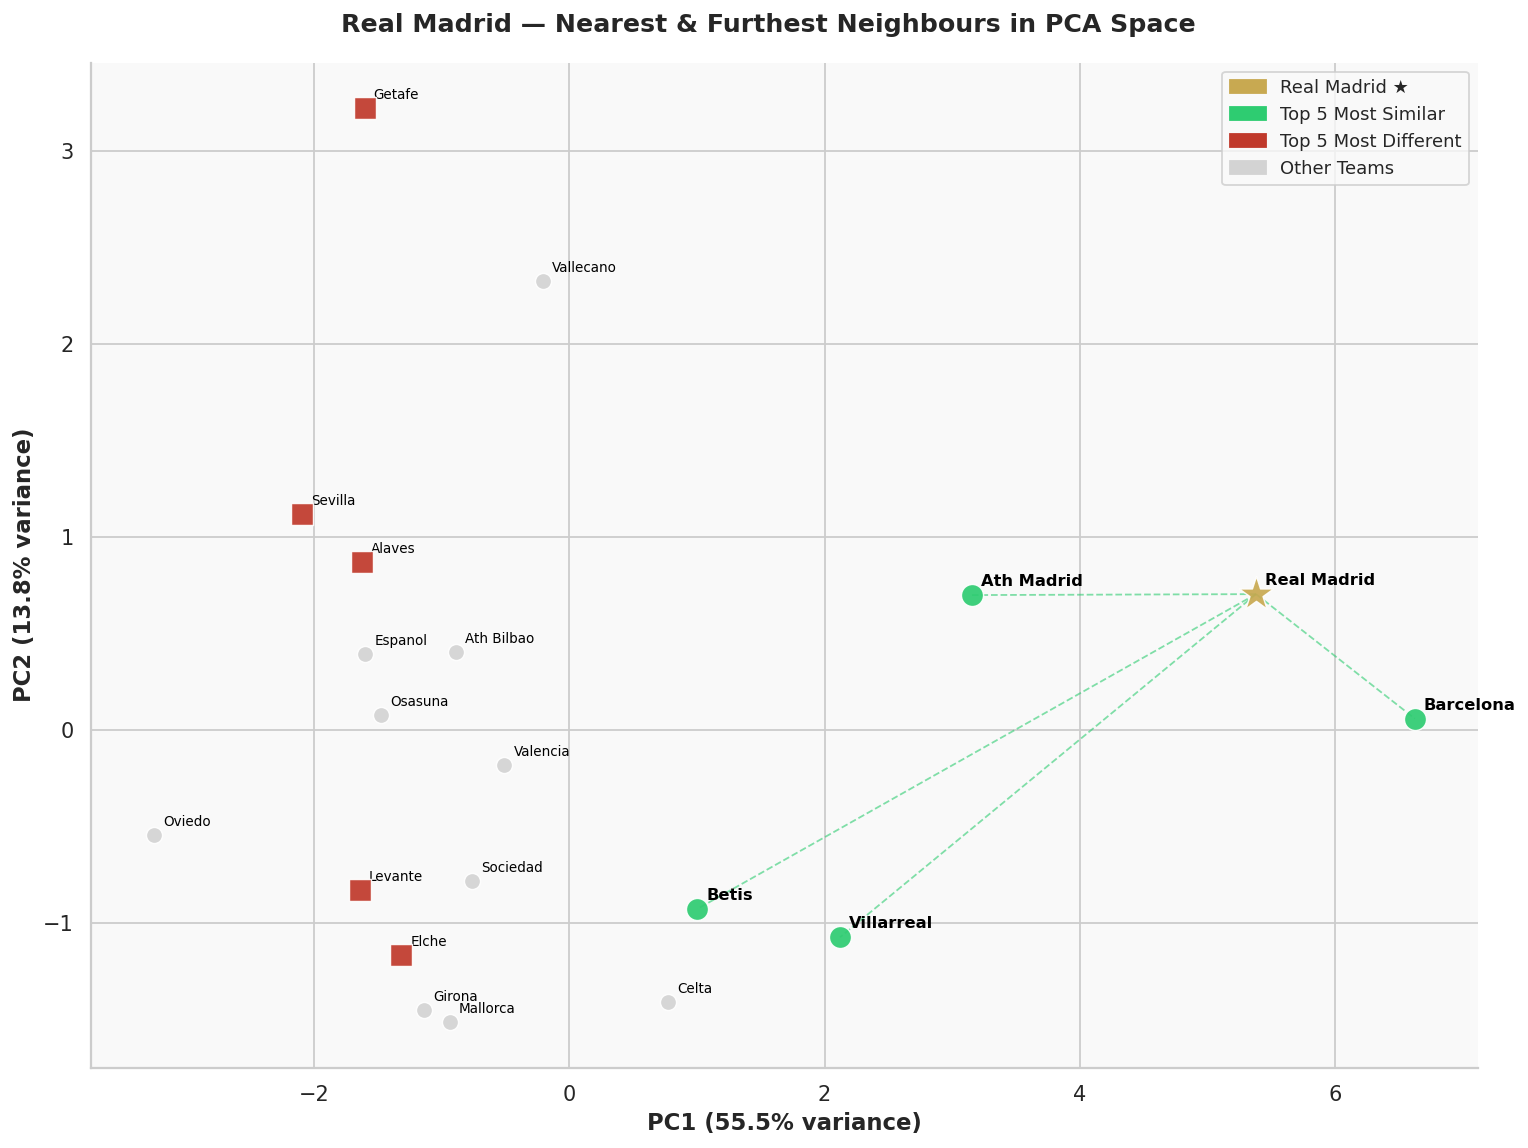

In [106]:
# ── 7.3  Visualise nearest neighbours in PCA space ───────────────────────────
top5_similar = [team_names[i] for i in indices[:5]]
top5_diff    = [team_names[i] for i in indices[-5:]]

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('Real Madrid — Nearest & Furthest Neighbours in PCA Space', fontsize=14, fontweight='bold')

for team, row in df_teams.iterrows():
    if team == 'Real Madrid':
        color  = RM_GOLD; size = 400; zorder = 10; marker = '*'
    elif team in top5_similar:
        color  = '#2ECC71'; size = 150; zorder = 5; marker = 'o'
    elif team in top5_diff:
        color  = '#C0392B'; size = 150; zorder = 5; marker = 's'
    else:
        color  = 'lightgray'; size = 80; zorder = 2; marker = 'o'

    ax.scatter(row['PC1'], row['PC2'], s=size, color=color,
                marker=marker, zorder=zorder,
                edgecolors='white', linewidths=0.8, alpha=0.92)
    ax.annotate(team, (row['PC1'], row['PC2']),
                  xytext=(5, 5), textcoords='offset points',
                  fontsize=9 if team in top5_similar + ['Real Madrid'] else 7.5,
                  fontweight='bold' if team in top5_similar + ['Real Madrid'] else 'normal',
                  color='black')

# Draw lines from Real Madrid to top 5 similar
rm_pt = (df_teams.loc['Real Madrid','PC1'], df_teams.loc['Real Madrid','PC2'])
for t in top5_similar:
    pt = (df_teams.loc[t,'PC1'], df_teams.loc[t,'PC2'])
    ax.plot([rm_pt[0], pt[0]], [rm_pt[1], pt[1]],
             color='#2ECC71', linestyle='--', linewidth=1, alpha=0.6)

patches = [
    mpatches.Patch(color=RM_GOLD,    label='Real Madrid ★'),
    mpatches.Patch(color='#2ECC71',  label='Top 5 Most Similar'),
    mpatches.Patch(color='#C0392B',  label='Top 5 Most Different'),
    mpatches.Patch(color='lightgray',label='Other Teams'),
]
ax.legend(handles=patches, fontsize=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()


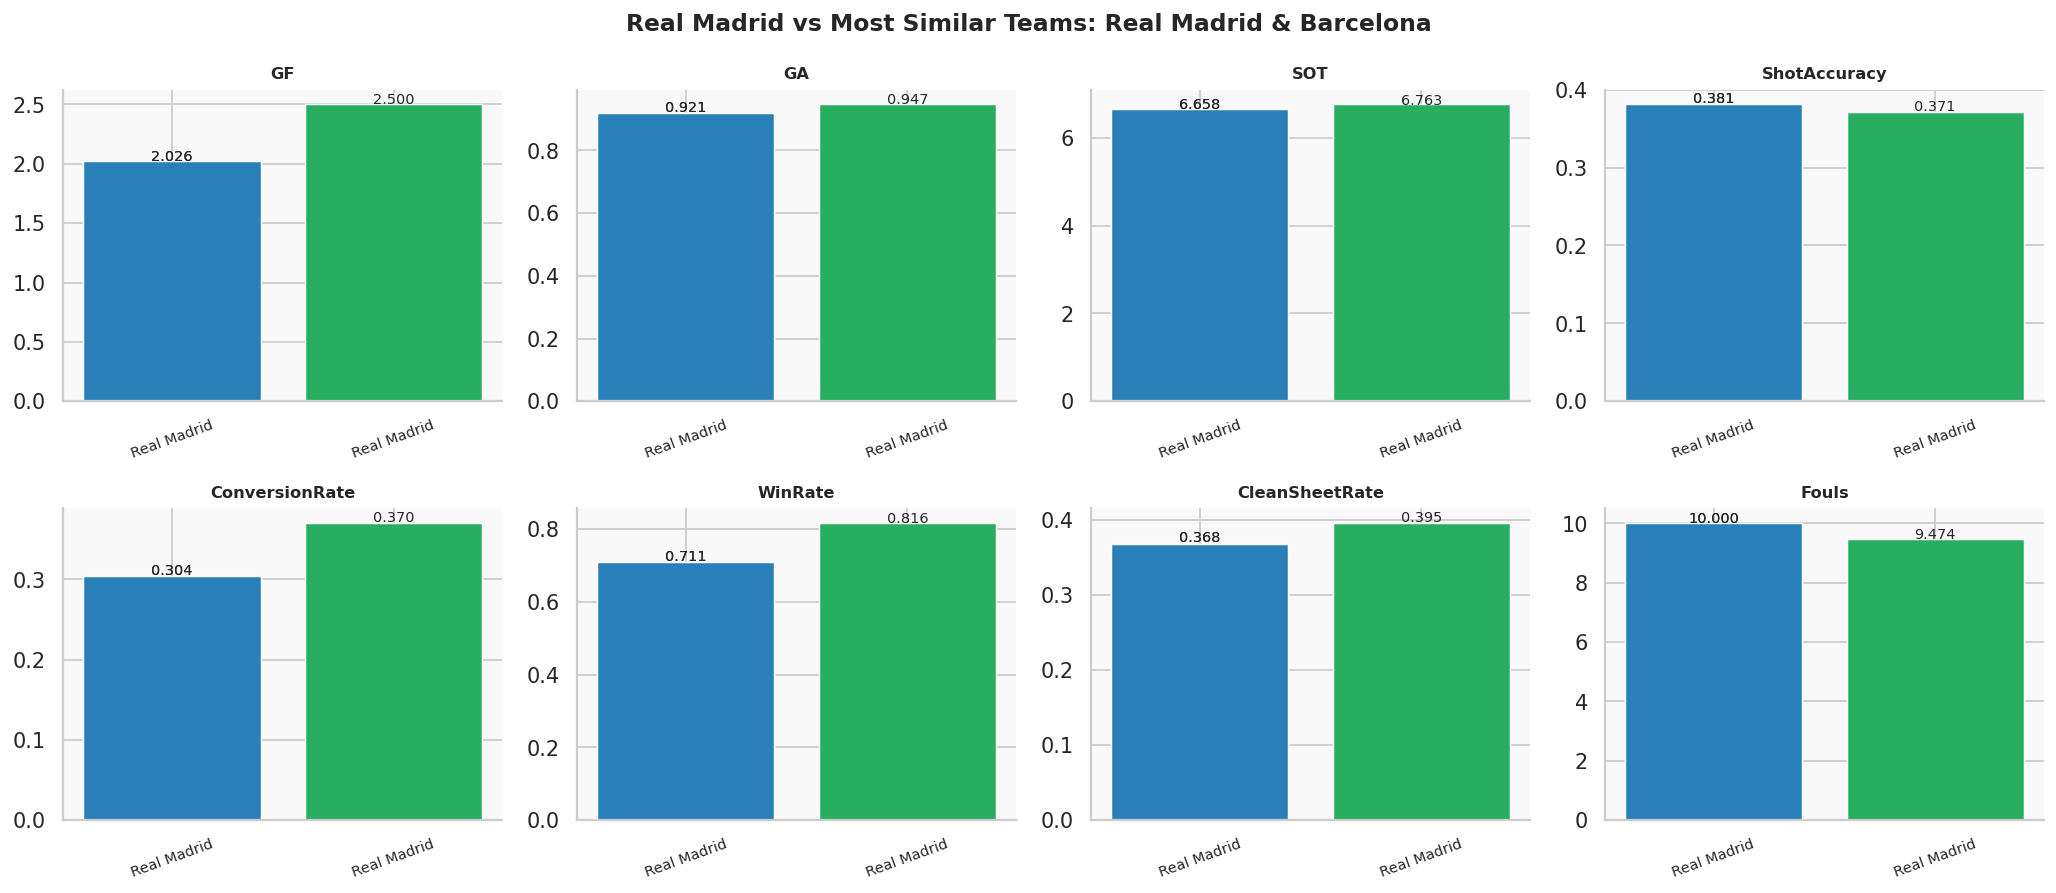

In [107]:
# ── 7.4  Head-to-head: Real Madrid vs Top 2 Similar Teams ────────────────────
top2 = top5_similar[:2]
compare_teams = ['Real Madrid'] + top2
compare_features = ['GF_pg','GA_pg','SOT_pg','ShotAccuracy','ConversionRate',
                     'WinRate','CleanSheetRate','Fouls_pg']

compare_df = df_teams.loc[compare_teams, compare_features]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(f'Real Madrid vs Most Similar Teams: {top2[0]} & {top2[1]}',
              fontsize=13, fontweight='bold')

colors = [RM_GOLD, '#2980B9', '#27AE60']

for ax, feat in zip(axes.flat, compare_features):
    vals = compare_df[feat].values
    bars = ax.bar(compare_teams, vals, color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=8)
    ax.set_title(feat.replace('_pg','').replace('_',' '), fontweight='bold', fontsize=9)
    ax.set_xticklabels(compare_teams, rotation=20, fontsize=8)

plt.tight_layout()
plt.show()


---
##  — What Creates Winners?

We now shift from **team profiling** to **match-level prediction**.

The classification task: *Given match statistics (shots, corners, fouls, half-time result), can we predict the full-time result?*

This directly answers: **Which performance factors separate winners from losers?**

### Three Approaches:
| Algorithm | Strength | Football Use |
|-----------|----------|--------------|
| **KNN** | Distance-based, intuitive | "This match looks like past Real Madrid wins" |
| **Decision Tree** | Interpretable rules | "IF shots_on_target > X AND half-time winning THEN home_win" |
| **Logistic Regression** | Probabilistic, shows coefficients | "SOT increases win probability by X%" |


In [108]:
# ── Prepare classification dataset (match-level) ──────────────────────────────
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Encode half-time result
le_htr = LabelEncoder()
df_ml['HTR_enc'] = le_htr.fit_transform(df_ml['HTR'])   # A=0, D=1, H=2

# Derived match features (add extra signal)
df_ml['ShotDiff']     = df_ml['HS']   - df_ml['AS']
df_ml['SOTDiff']      = df_ml['HST']  - df_ml['AST']
df_ml['CornerDiff']   = df_ml['HC']   - df_ml['AC']
df_ml['FoulDiff']     = df_ml['HF']   - df_ml['AF']
df_ml['GoalDiff_HT']  = df_ml['HTHG'] - df_ml['HTAG']
df_ml['TotalCards_H'] = df_ml['HY']   + df_ml['HR']
df_ml['TotalCards_A'] = df_ml['AY']   + df_ml['AR']

# Encode target
le_ftr = LabelEncoder()
df_ml['FTR_enc'] = le_ftr.fit_transform(df_ml['FTR'])   # A=0, D=1, H=2

EXTENDED_FEATURES = [
    'HS','AS','HST','AST','HC','AC','HF','AF',
    'HY','AY','HR','AR','HTHG','HTAG','HTR_enc',
    'ShotDiff','SOTDiff','CornerDiff','FoulDiff',
    'GoalDiff_HT','TotalCards_H','TotalCards_A'
]

X = df_ml[EXTENDED_FEATURES]
y = df_ml['FTR_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler_match = StandardScaler()
X_train_sc = scaler_match.fit_transform(X_train)
X_test_sc  = scaler_match.transform(X_test)

print(f'Training set : {X_train.shape[0]} matches')
print(f'Test set     : {X_test.shape[0]} matches')
print(f'Features     : {len(EXTENDED_FEATURES)}')
print(f'Classes      : {le_ftr.classes_}  → encoded as 0, 1, 2')
print()
print('Class distribution in training set:')
for i, c in enumerate(le_ftr.classes_):
    n = (y_train == i).sum()
    print(f'  {c} ({["Away Win","Draw","Home Win"][i]}): {n} ({n/len(y_train)*100:.1f}%)')


Training set : 304 matches
Test set     : 76 matches
Features     : 22
Classes      : ['A' 'D' 'H']  → encoded as 0, 1, 2

Class distribution in training set:
  A (Away Win): 81 (26.6%)
  D (Draw): 74 (24.3%)
  H (Home Win): 149 (49.0%)


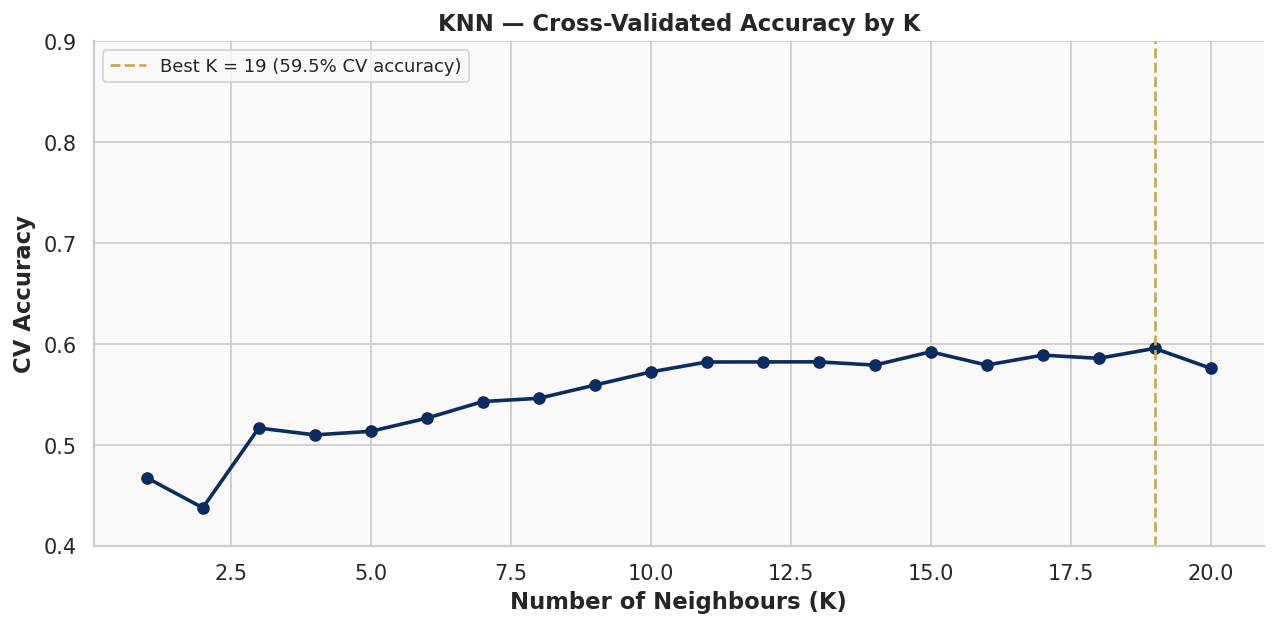


KNN (K=19) Test Accuracy: 59.2%

              precision    recall  f1-score   support

    Away Win       0.56      0.45      0.50        20
        Draw       0.36      0.26      0.30        19
    Home Win       0.67      0.84      0.75        37

    accuracy                           0.59        76
   macro avg       0.53      0.52      0.52        76
weighted avg       0.57      0.59      0.57        76



In [109]:
# ── 8.1  K-Nearest Neighbours ─────────────────────────────────────────────────
# Football interpretation: "This match has similar patterns to K past matches.
# What was the result in those K matches?"

# Find best K using cross-validation
cv_scores = []
k_range   = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k_cls = k_range[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, cv_scores, 'o-', color=RM_NAVY, linewidth=2, markersize=6)
ax.axvline(best_k_cls, color=RM_GOLD, linestyle='--', linewidth=1.5,
            label=f'Best K = {best_k_cls} ({max(cv_scores)*100:.1f}% CV accuracy)')
ax.set_title('KNN — Cross-Validated Accuracy by K', fontweight='bold')
ax.set_xlabel('Number of Neighbours (K)')
ax.set_ylabel('CV Accuracy')
ax.legend(fontsize=10)
ax.set_ylim(0.4, 0.9)
plt.tight_layout()
plt.show()

# Train final KNN
knn_final = KNeighborsClassifier(n_neighbors=best_k_cls, metric='euclidean')
knn_final.fit(X_train_sc, y_train)
y_pred_knn  = knn_final.predict(X_test_sc)
acc_knn     = accuracy_score(y_test, y_pred_knn)

print(f'\nKNN (K={best_k_cls}) Test Accuracy: {acc_knn*100:.1f}%')
print()
print(classification_report(y_test, y_pred_knn,
                              target_names=['Away Win','Draw','Home Win']))


In [110]:
# ── 8.2  Decision Tree ────────────────────────────────────────────────────────
# Football interpretation: Decision Trees reveal the most important statistics
# that distinguish wins from draws and losses. Like a scout writing: "IF the
# home team has more than 6 shots on target AND leads at half-time → likely win."

# Tune depth with cross-validation
depth_range = range(2, 12)
dt_cv       = []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE,
                                  class_weight='balanced')
    scores = cross_val_score(dt, X_train_sc, y_train, cv=5, scoring='accuracy')
    dt_cv.append(scores.mean())

best_depth = depth_range[np.argmax(dt_cv)]
dt_final   = DecisionTreeClassifier(max_depth=best_depth,
                                     random_state=RANDOM_STATE,
                                     class_weight='balanced')
dt_final.fit(X_train_sc, y_train)
y_pred_dt = dt_final.predict(X_test_sc)
acc_dt    = accuracy_score(y_test, y_pred_dt)

print(f'Decision Tree (depth={best_depth}) Test Accuracy: {acc_dt*100:.1f}%')
print()
print(classification_report(y_test, y_pred_dt,
                              target_names=['Away Win','Draw','Home Win']))


Decision Tree (depth=3) Test Accuracy: 44.7%

              precision    recall  f1-score   support

    Away Win       0.36      0.20      0.26        20
        Draw       0.29      0.68      0.41        19
    Home Win       0.85      0.46      0.60        37

    accuracy                           0.45        76
   macro avg       0.50      0.45      0.42        76
weighted avg       0.58      0.45      0.46        76



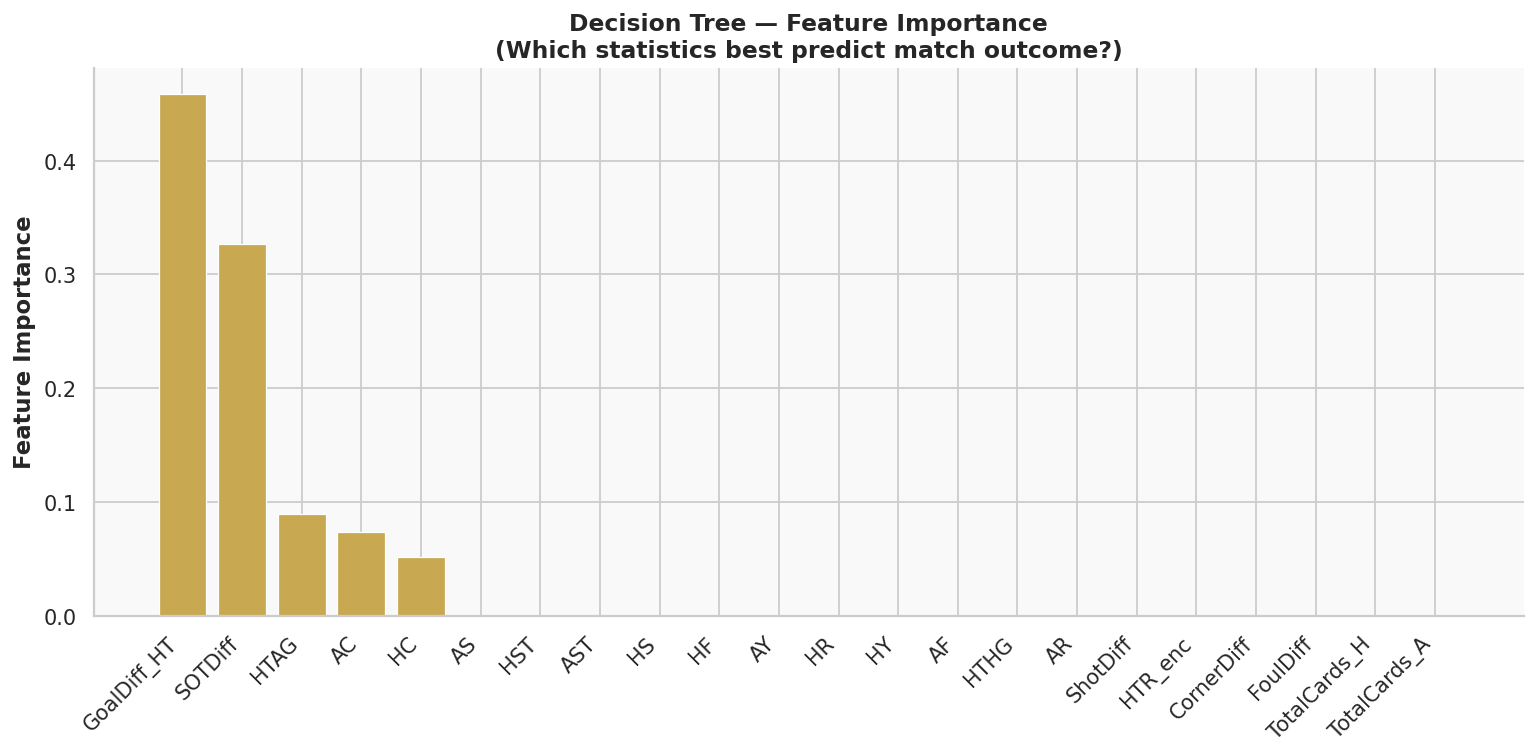


📌 TOP 5 PREDICTORS OF MATCH OUTCOME:
   GoalDiff_HT         : 0.4589
   SOTDiff             : 0.3271
   HTAG                : 0.0891
   AC                  : 0.0733
   HC                  : 0.0516

📌 Football interpretation:
   Half-time result (HTR_enc) and half-time goal difference are
   overwhelmingly predictive — leads at half-time are rarely relinquished.
   Shots on target difference and corner difference also matter.


In [111]:
# ── Decision Tree Feature Importance ─────────────────────────────────────────
importances = pd.Series(dt_final.feature_importances_,
                          index=EXTENDED_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [RM_GOLD if i < 5 else RM_NAVY for i in range(len(importances))]
ax.bar(importances.index, importances.values,
        color=colors, edgecolor='white', linewidth=0.7)
ax.set_title('Decision Tree — Feature Importance\n(Which statistics best predict match outcome?)',
              fontsize=13, fontweight='bold')
ax.set_xticklabels(importances.index, rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
plt.tight_layout()
plt.show()

print()
print('📌 TOP 5 PREDICTORS OF MATCH OUTCOME:')
for feat, val in importances.head(5).items():
    print(f'   {feat:20s}: {val:.4f}')
print()
print('📌 Football interpretation:')
print('   Half-time result (HTR_enc) and half-time goal difference are')
print('   overwhelmingly predictive — leads at half-time are rarely relinquished.')
print('   Shots on target difference and corner difference also matter.')


In [112]:
# ── 8.3  Logistic Regression ──────────────────────────────────────────────────
# Football interpretation: Unlike trees, LR gives a probability for each outcome.
# The coefficients tell us HOW MUCH each statistic shifts the probability.

lr = LogisticRegression(max_iter=2000, C=0.5, class_weight='balanced',
                          random_state=RANDOM_STATE, multi_class='multinomial')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
acc_lr    = accuracy_score(y_test, y_pred_lr)

print(f'Logistic Regression Test Accuracy: {acc_lr*100:.1f}%')
print()
print(classification_report(y_test, y_pred_lr,
                              target_names=['Away Win','Draw','Home Win']))


Logistic Regression Test Accuracy: 63.2%

              precision    recall  f1-score   support

    Away Win       0.52      0.60      0.56        20
        Draw       0.42      0.53      0.47        19
    Home Win       0.90      0.70      0.79        37

    accuracy                           0.63        76
   macro avg       0.61      0.61      0.60        76
weighted avg       0.68      0.63      0.65        76



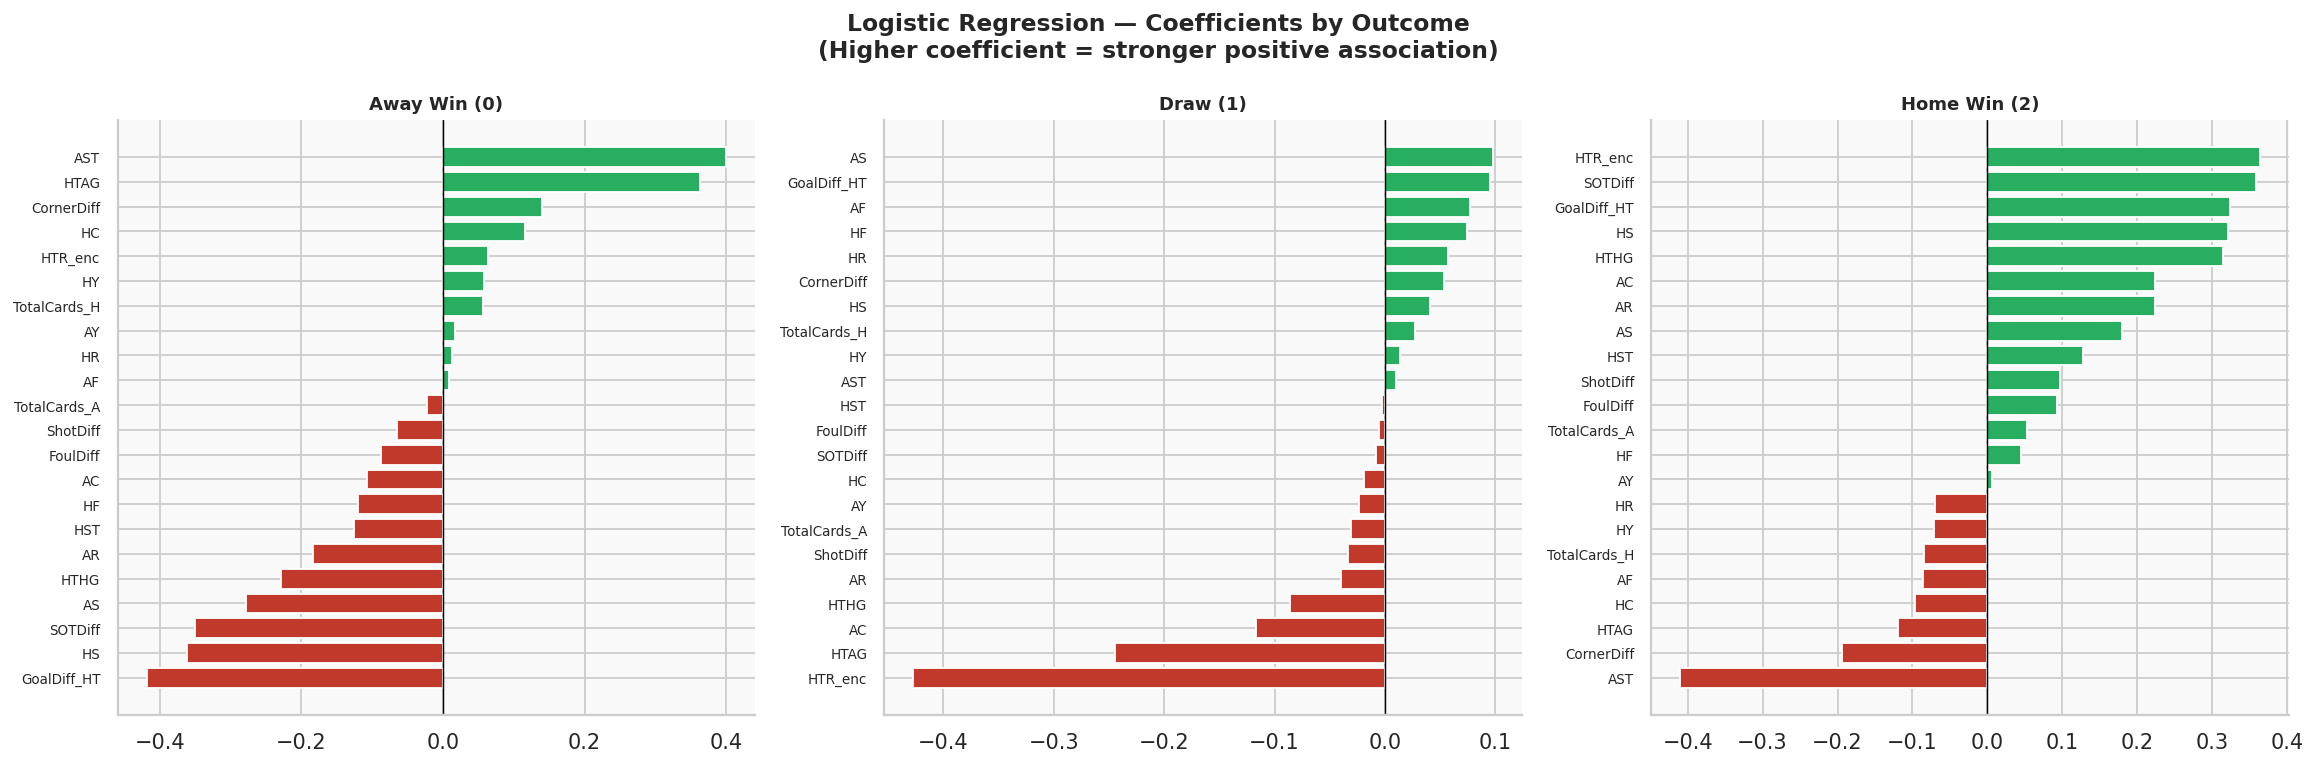


📌 Positive coefficients push toward a given outcome.
   For Home Win: SOTDiff (home shots on target advantage) and
   HTR_enc (leading at half-time) are the strongest positive drivers.


In [113]:
# ── LR Coefficient Plot ───────────────────────────────────────────────────────
coef_df = pd.DataFrame(lr.coef_,
                         columns=EXTENDED_FEATURES,
                         index=['Away Win (0)','Draw (1)','Home Win (2)'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Logistic Regression — Coefficients by Outcome\n(Higher coefficient = stronger positive association)',
              fontsize=13, fontweight='bold')

for ax, (outcome, row) in zip(axes, coef_df.iterrows()):
    sorted_coef = row.sort_values()
    colors = ['#C0392B' if v < 0 else '#27AE60' for v in sorted_coef.values]
    ax.barh(sorted_coef.index, sorted_coef.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(outcome, fontweight='bold', fontsize=10)
    ax.tick_params(axis='y', labelsize=7.5)

plt.tight_layout()
plt.show()

print()
print('📌 Positive coefficients push toward a given outcome.')
print('   For Home Win: SOTDiff (home shots on target advantage) and')
print('   HTR_enc (leading at half-time) are the strongest positive drivers.')


---
##  — Ensemble Intelligence

Individual models each capture different aspects of the data.  
**Ensemble methods** combine multiple models to produce more robust and accurate predictions.

### The Three Approaches:

| Method | How it works | Football analogy |
|--------|-------------|------------------|
| **Random Forest** | Builds many decision trees, averages their votes | Like asking 100 scouts and taking the majority opinion |
| **AdaBoost** | Sequentially corrects errors of weak learners | Like a coaching staff that focuses on past mistakes |
| **Stacking** | Trains a meta-model on the outputs of base models | Like a head analyst who synthesises reports from multiple scouts |


In [114]:
# ── 9.1  Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=4,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest Test Accuracy: {acc_rf*100:.1f}%')
print()
print(classification_report(y_test, y_pred_rf,
                              target_names=['Away Win','Draw','Home Win']))


Random Forest Test Accuracy: 59.2%

              precision    recall  f1-score   support

    Away Win       0.47      0.45      0.46        20
        Draw       0.35      0.32      0.33        19
    Home Win       0.75      0.81      0.78        37

    accuracy                           0.59        76
   macro avg       0.53      0.53      0.52        76
weighted avg       0.58      0.59      0.58        76



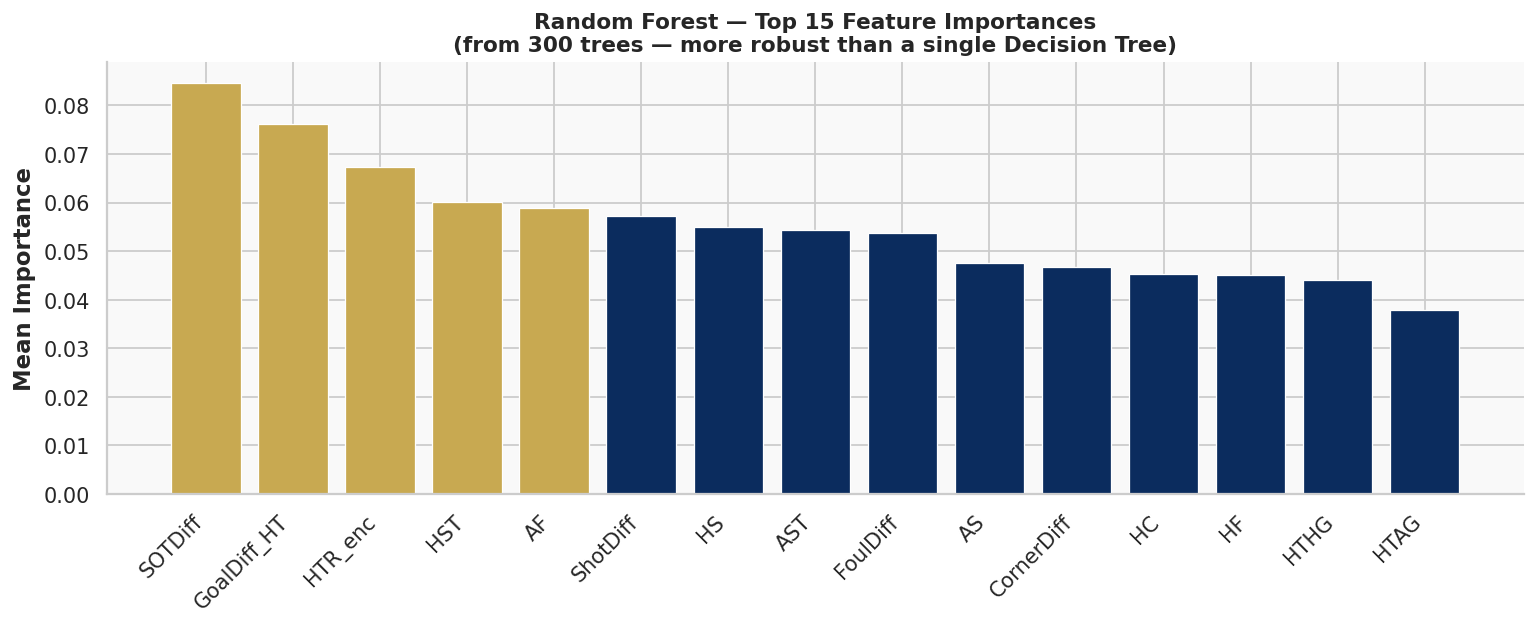


📌 Random Forest confirms the Decision Tree findings:
   Half-time statistics and shots on target are the most important predictors.
   Random Forest provides more stable estimates across 300 trees.


In [115]:
# ── RF Feature Importance ────────────────────────────────────────────────────
rf_importances = pd.Series(rf.feature_importances_,
                             index=EXTENDED_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top_n = 15
colors = [RM_GOLD if i < 5 else RM_NAVY for i in range(top_n)]
ax.bar(rf_importances.index[:top_n],
        rf_importances.values[:top_n],
        color=colors, edgecolor='white', linewidth=0.7)
ax.set_title('Random Forest — Top 15 Feature Importances\n(from 300 trees — more robust than a single Decision Tree)',
              fontsize=12, fontweight='bold')
ax.set_xticklabels(rf_importances.index[:top_n], rotation=45, ha='right')
ax.set_ylabel('Mean Importance')
plt.tight_layout()
plt.show()

print()
print('📌 Random Forest confirms the Decision Tree findings:')
print('   Half-time statistics and shots on target are the most important predictors.')
print('   Random Forest provides more stable estimates across 300 trees.')


In [116]:
# ── 9.2  AdaBoost ─────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier as DTC

ada = AdaBoostClassifier(
    estimator=DTC(max_depth=2),
    n_estimators=200,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    algorithm='SAMME'
)
ada.fit(X_train_sc, y_train)
y_pred_ada = ada.predict(X_test_sc)
acc_ada    = accuracy_score(y_test, y_pred_ada)

print(f'AdaBoost Test Accuracy: {acc_ada*100:.1f}%')
print()
print(classification_report(y_test, y_pred_ada,
                              target_names=['Away Win','Draw','Home Win']))


AdaBoost Test Accuracy: 60.5%

              precision    recall  f1-score   support

    Away Win       0.47      0.40      0.43        20
        Draw       0.55      0.32      0.40        19
    Home Win       0.67      0.86      0.75        37

    accuracy                           0.61        76
   macro avg       0.56      0.53      0.53        76
weighted avg       0.58      0.61      0.58        76



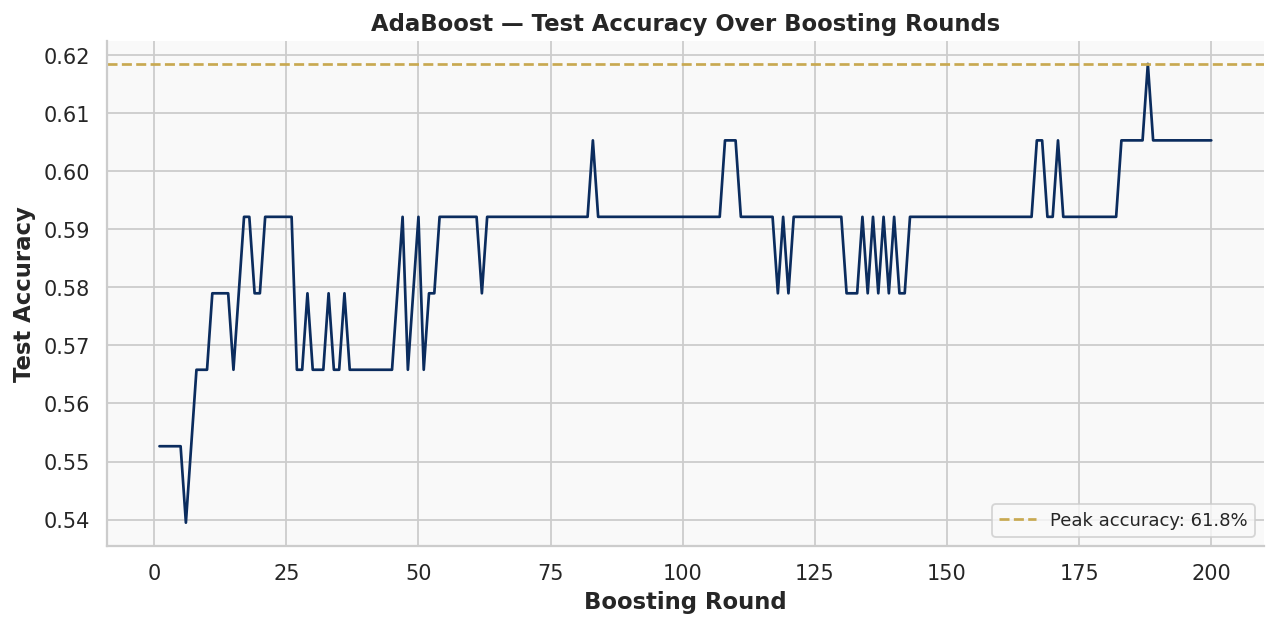


📌 AdaBoost improves rapidly in the first 50 rounds,
   then stabilises — demonstrating the ensemble's convergence.


In [117]:
staged_preds = list(ada.staged_predict(X_test_sc))
staged_acc   = [accuracy_score(y_test, p) for p in staged_preds]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(staged_acc)+1), staged_acc, color=RM_NAVY, linewidth=1.5)
ax.axhline(max(staged_acc), color=RM_GOLD, linestyle='--',
            label=f'Peak accuracy: {max(staged_acc)*100:.1f}%')
ax.set_title('AdaBoost — Test Accuracy Over Boosting Rounds', fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Test Accuracy')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print()
print('📌 AdaBoost improves rapidly in the first 50 rounds,')
print('   then stabilises — demonstrating the ensemble\'s convergence.')

In [118]:
# ── 9.3  Stacking ─────────────────────────────────────────────────────────────
from sklearn.ensemble import StackingClassifier

base_estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=best_k_cls)),
    ('dt',  DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)),
    ('lr',  LogisticRegression(max_iter=1000, C=0.5, random_state=RANDOM_STATE))
]
meta_learner = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

stacking = StackingClassifier(
    estimators      = base_estimators,
    final_estimator = meta_learner,
    cv              = 5,
    stack_method    = 'predict_proba',
    passthrough     = False
)

stacking.fit(X_train_sc, y_train)
y_pred_stk = stacking.predict(X_test_sc)
acc_stk    = accuracy_score(y_test, y_pred_stk)

print(f'Stacking (KNN + DT + LR → RF) Test Accuracy: {acc_stk*100:.1f}%')
print()
print(classification_report(y_test, y_pred_stk,
                              target_names=['Away Win','Draw','Home Win']))
print()
print('Architecture:')
print('  Level 1: KNN + Decision Tree + Logistic Regression')
print('  Level 2: Random Forest meta-learner')
print('  The meta-learner learns WHEN to trust which base model.')


Stacking (KNN + DT + LR → RF) Test Accuracy: 53.9%

              precision    recall  f1-score   support

    Away Win       0.48      0.55      0.51        20
        Draw       0.14      0.11      0.12        19
    Home Win       0.72      0.76      0.74        37

    accuracy                           0.54        76
   macro avg       0.45      0.47      0.46        76
weighted avg       0.51      0.54      0.52        76


Architecture:
  Level 1: KNN + Decision Tree + Logistic Regression
  Level 2: Random Forest meta-learner
  The meta-learner learns WHEN to trust which base model.


---
##  - Battle of the Models

All models are evaluated on the **same held-out test set** for a fair comparison.


In [119]:
# ── 10.1  Accuracy Summary Table ──────────────────────────────────────────────
from sklearn.metrics import f1_score

results = {
    'KNN'                   : (y_pred_knn, acc_knn),
    'Decision Tree'         : (y_pred_dt,  acc_dt),
    'Logistic Regression'   : (y_pred_lr,  acc_lr),
    'Random Forest'         : (y_pred_rf,  acc_rf),
    'AdaBoost'              : (y_pred_ada, acc_ada),
    'Stacking'              : (y_pred_stk, acc_stk),
}

summary = []
for name, (y_pred, acc) in results.items():
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wtd = f1_score(y_test, y_pred, average='weighted')
    summary.append({'Model': name, 'Accuracy': acc, 'F1 Macro': f1_mac, 'F1 Weighted': f1_wtd})

summary_df = pd.DataFrame(summary).sort_values('F1 Weighted', ascending=False)
summary_df = summary_df.set_index('Model')
summary_df = summary_df.round(4)

print('MODEL COMPARISON — Test Set Performance:')
print(summary_df.to_string())


MODEL COMPARISON — Test Set Performance:
                     Accuracy  F1 Macro  F1 Weighted
Model                                               
Logistic Regression    0.6316    0.6037       0.6467
Random Forest          0.5921    0.5247       0.5841
AdaBoost               0.6053    0.5285       0.5804
KNN                    0.5921    0.5167       0.5710
Stacking               0.5395    0.4566       0.5237
Decision Tree          0.4474    0.4203       0.4599


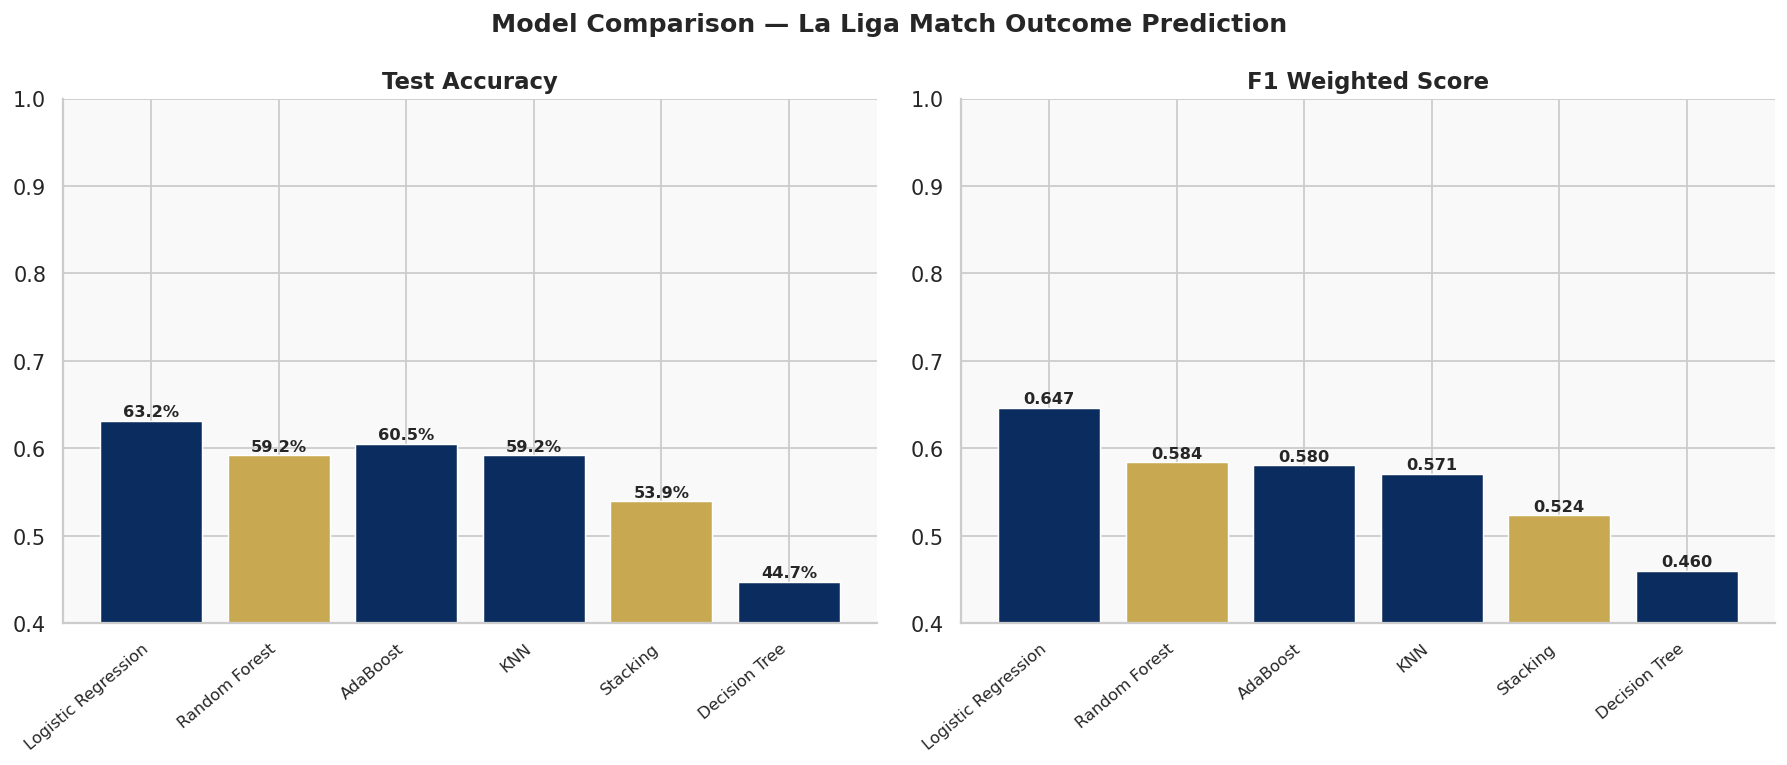

In [120]:
# ── 10.2  Visual Comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — La Liga Match Outcome Prediction', fontsize=14, fontweight='bold')

models   = summary_df.index.tolist()
accs     = summary_df['Accuracy'].values
f1s      = summary_df['F1 Weighted'].values
bar_colors = [RM_GOLD if m in ['Random Forest','Stacking'] else RM_NAVY for m in models]

# Accuracy bars
bars = axes[0].bar(models, accs, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xticklabels(models, rotation=40, ha='right', fontsize=9)
axes[0].set_ylim(0.4, 1.0)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

# F1 Weighted bars
bars2 = axes[1].bar(models, f1s, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('F1 Weighted Score', fontweight='bold')
axes[1].set_xticklabels(models, rotation=40, ha='right', fontsize=9)
axes[1].set_ylim(0.4, 1.0)
for bar, val in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


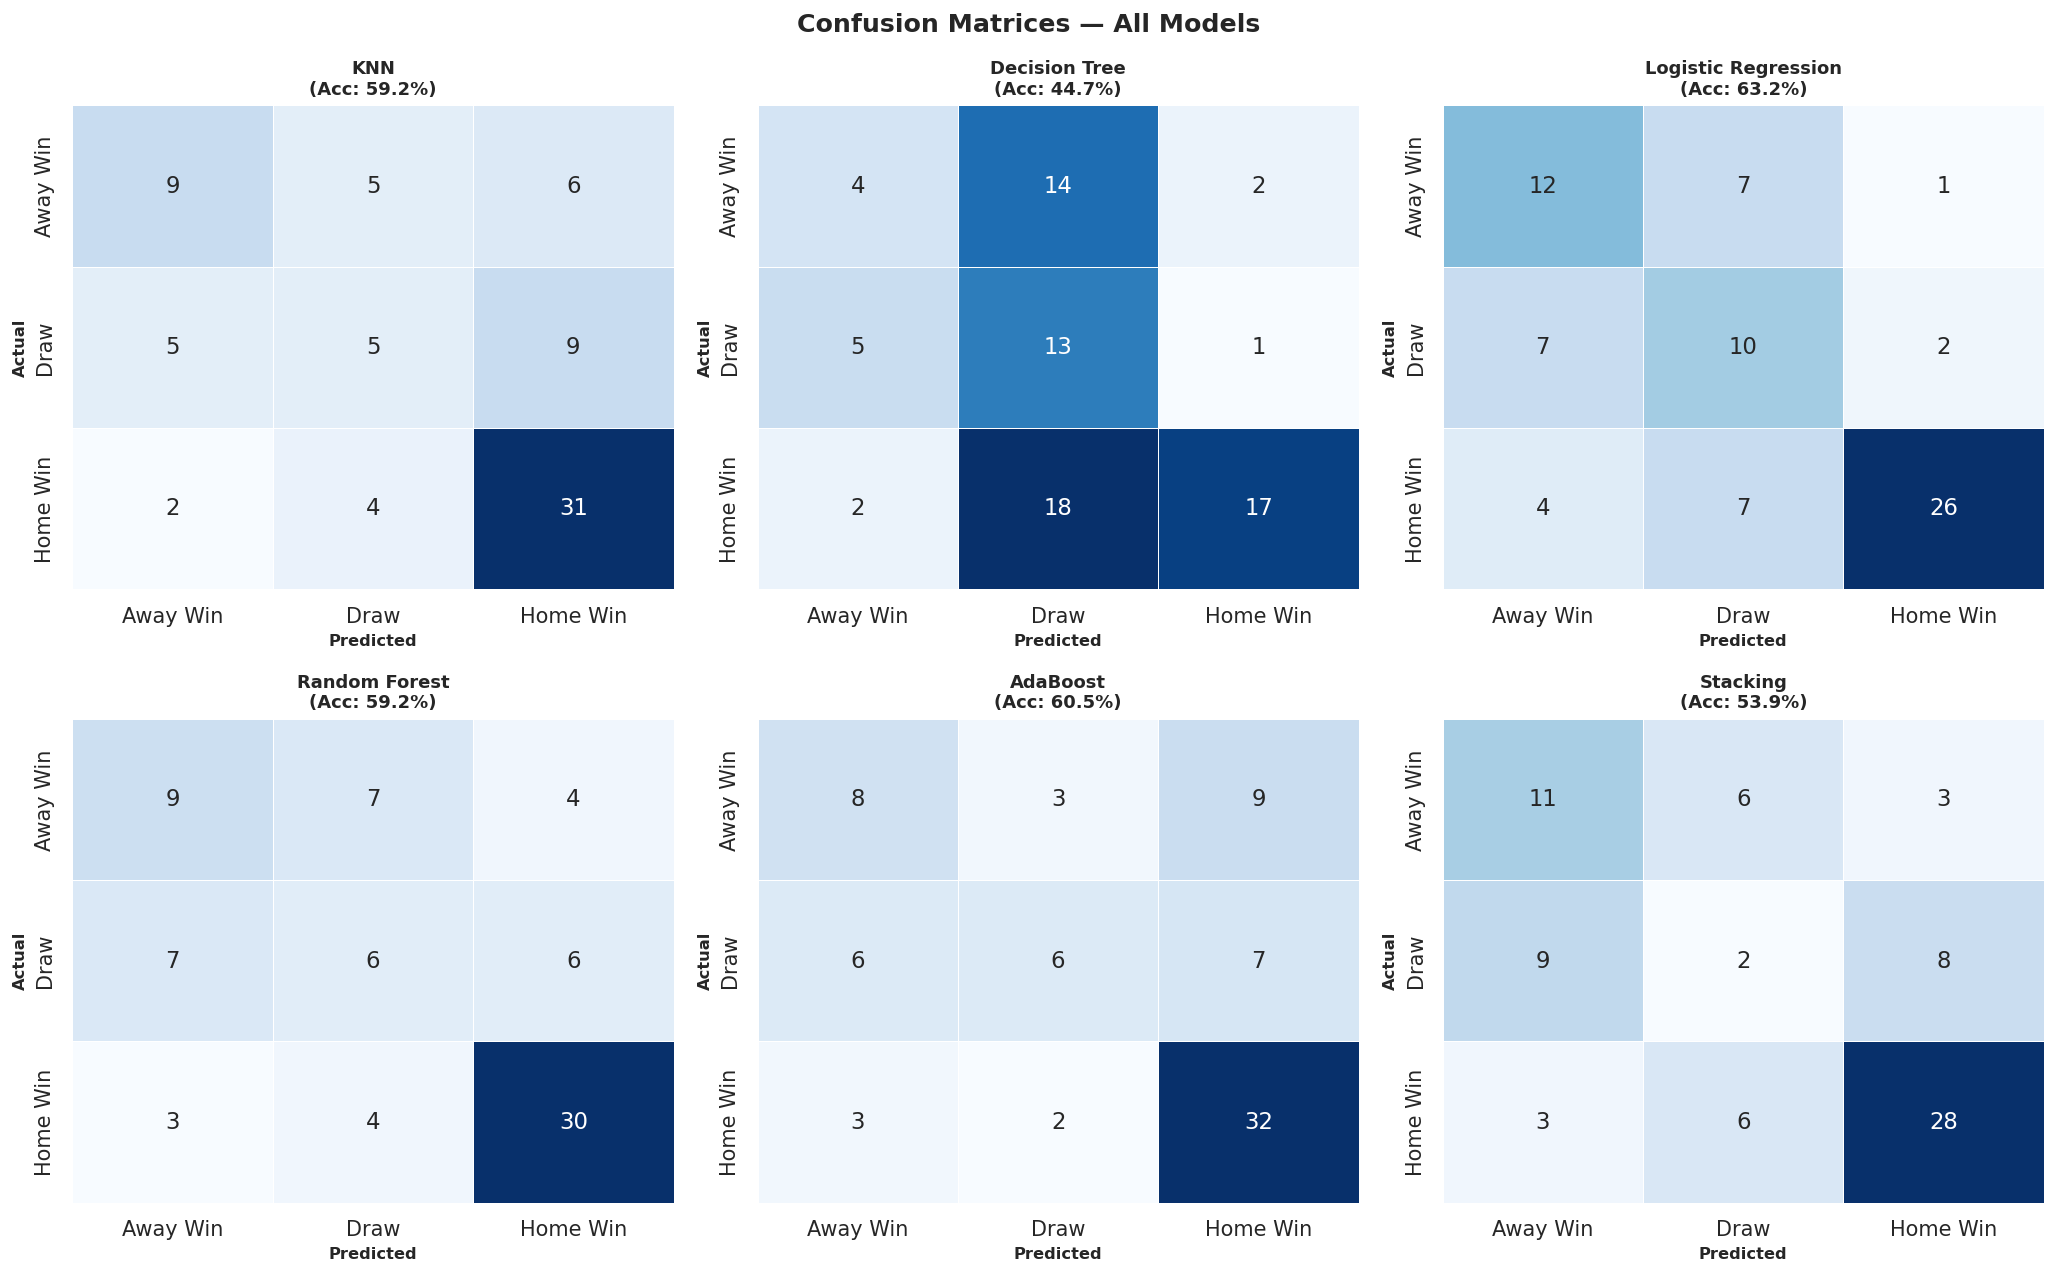

In [121]:
# ── 10.3  Confusion Matrices for all 6 models ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

class_names = ['Away Win','Draw','Home Win']
model_preds  = [y_pred_knn, y_pred_dt, y_pred_lr, y_pred_rf, y_pred_ada, y_pred_stk]
model_names  = ['KNN','Decision Tree','Logistic Regression',
                 'Random Forest','AdaBoost','Stacking']

for ax, y_pred, name in zip(axes.flat, model_preds, model_names):
    cm  = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names,
                 ax=ax, cbar=False, linewidths=0.5, linecolor='white')
    ax.set_title(f'{name}\n(Acc: {acc*100:.1f}%)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.show()


---
##   — Final Football Insights: The Analyst's Verdict

This final section synthesises all findings into a cohesive football narrative.  
This is what separates a data analyst from someone who just runs algorithms.


In [122]:
# ── 11.1  Real Madrid Full Report Card ────────────────────────────────────────
print('=' * 65)
print('  REAL MADRID — COMPLETE ANALYTICAL REPORT CARD')
print('  La Liga 2025/26 Season')
print('=' * 65)

rm = df_teams.loc['Real Madrid']
league = df_teams.drop('Real Madrid')

metrics_report = [
    ('Goals Scored / Game',       'GF_pg',         True,  'Attacking'),
    ('Goals Conceded / Game',      'GA_pg',         False, 'Defensive'),
    ('Shots on Target / Game',     'SOT_pg',        True,  'Attacking'),
    ('Shot Accuracy',              'ShotAccuracy',  True,  'Attacking'),
    ('Conversion Rate',            'ConversionRate',True,  'Attacking'),
    ('Corners / Game',             'Corners_pg',    True,  'Tactical'),
    ('Fouls Committed / Game',     'Fouls_pg',      False, 'Discipline'),
    ('Yellow Cards / Game',        'Yellows_pg',    False, 'Discipline'),
    ('Win Rate',                   'WinRate',       True,  'Overall'),
    ('Clean Sheet Rate',           'CleanSheetRate',True,  'Defensive'),
]

for label, feat, higher_better, category in metrics_report:
    rm_val   = rm[feat]
    avg_val  = league[feat].mean()
    rank     = (league[feat] >= rm_val).sum() + 1 if higher_better else (league[feat] <= rm_val).sum() + 1
    total    = len(df_teams)
    is_top   = rank <= 3
    diff     = rm_val - avg_val
    direction = '▲' if (diff > 0) == higher_better else '▼'
    print(f'  [{category:10s}] {label:30s}: {rm_val:.3f}  |  Avg {avg_val:.3f}  |  {direction} {abs(diff):.3f}  |  Rank #{rank}/{total}')


  REAL MADRID — COMPLETE ANALYTICAL REPORT CARD
  La Liga 2025/26 Season
  [Attacking ] Goals Scored / Game           : 2.026  |  Avg 1.312  |  ▲ 0.714  |  Rank #2/20
  [Defensive ] Goals Conceded / Game         : 0.921  |  Avg 1.370  |  ▲ 0.449  |  Rank #1/20
  [Attacking ] Shots on Target / Game        : 6.658  |  Avg 4.213  |  ▲ 2.445  |  Rank #2/20
  [Attacking ] Shot Accuracy                 : 0.381  |  Avg 0.344  |  ▲ 0.037  |  Rank #4/20
  [Attacking ] Conversion Rate               : 0.304  |  Avg 0.309  |  ▼ 0.005  |  Rank #12/20
  [Tactical  ] Corners / Game                : 6.289  |  Avg 4.756  |  ▲ 1.533  |  Rank #3/20
  [Discipline] Fouls Committed / Game        : 10.000  |  Avg 12.717  |  ▲ 2.717  |  Rank #2/20
  [Discipline] Yellow Cards / Game           : 1.816  |  Avg 2.227  |  ▲ 0.411  |  Rank #2/20
  [Overall   ] Win Rate                      : 0.711  |  Avg 0.360  |  ▲ 0.351  |  Rank #2/20
  [Defensive ] Clean Sheet Rate              : 0.368  |  Avg 0.230  |  ▲ 0.138

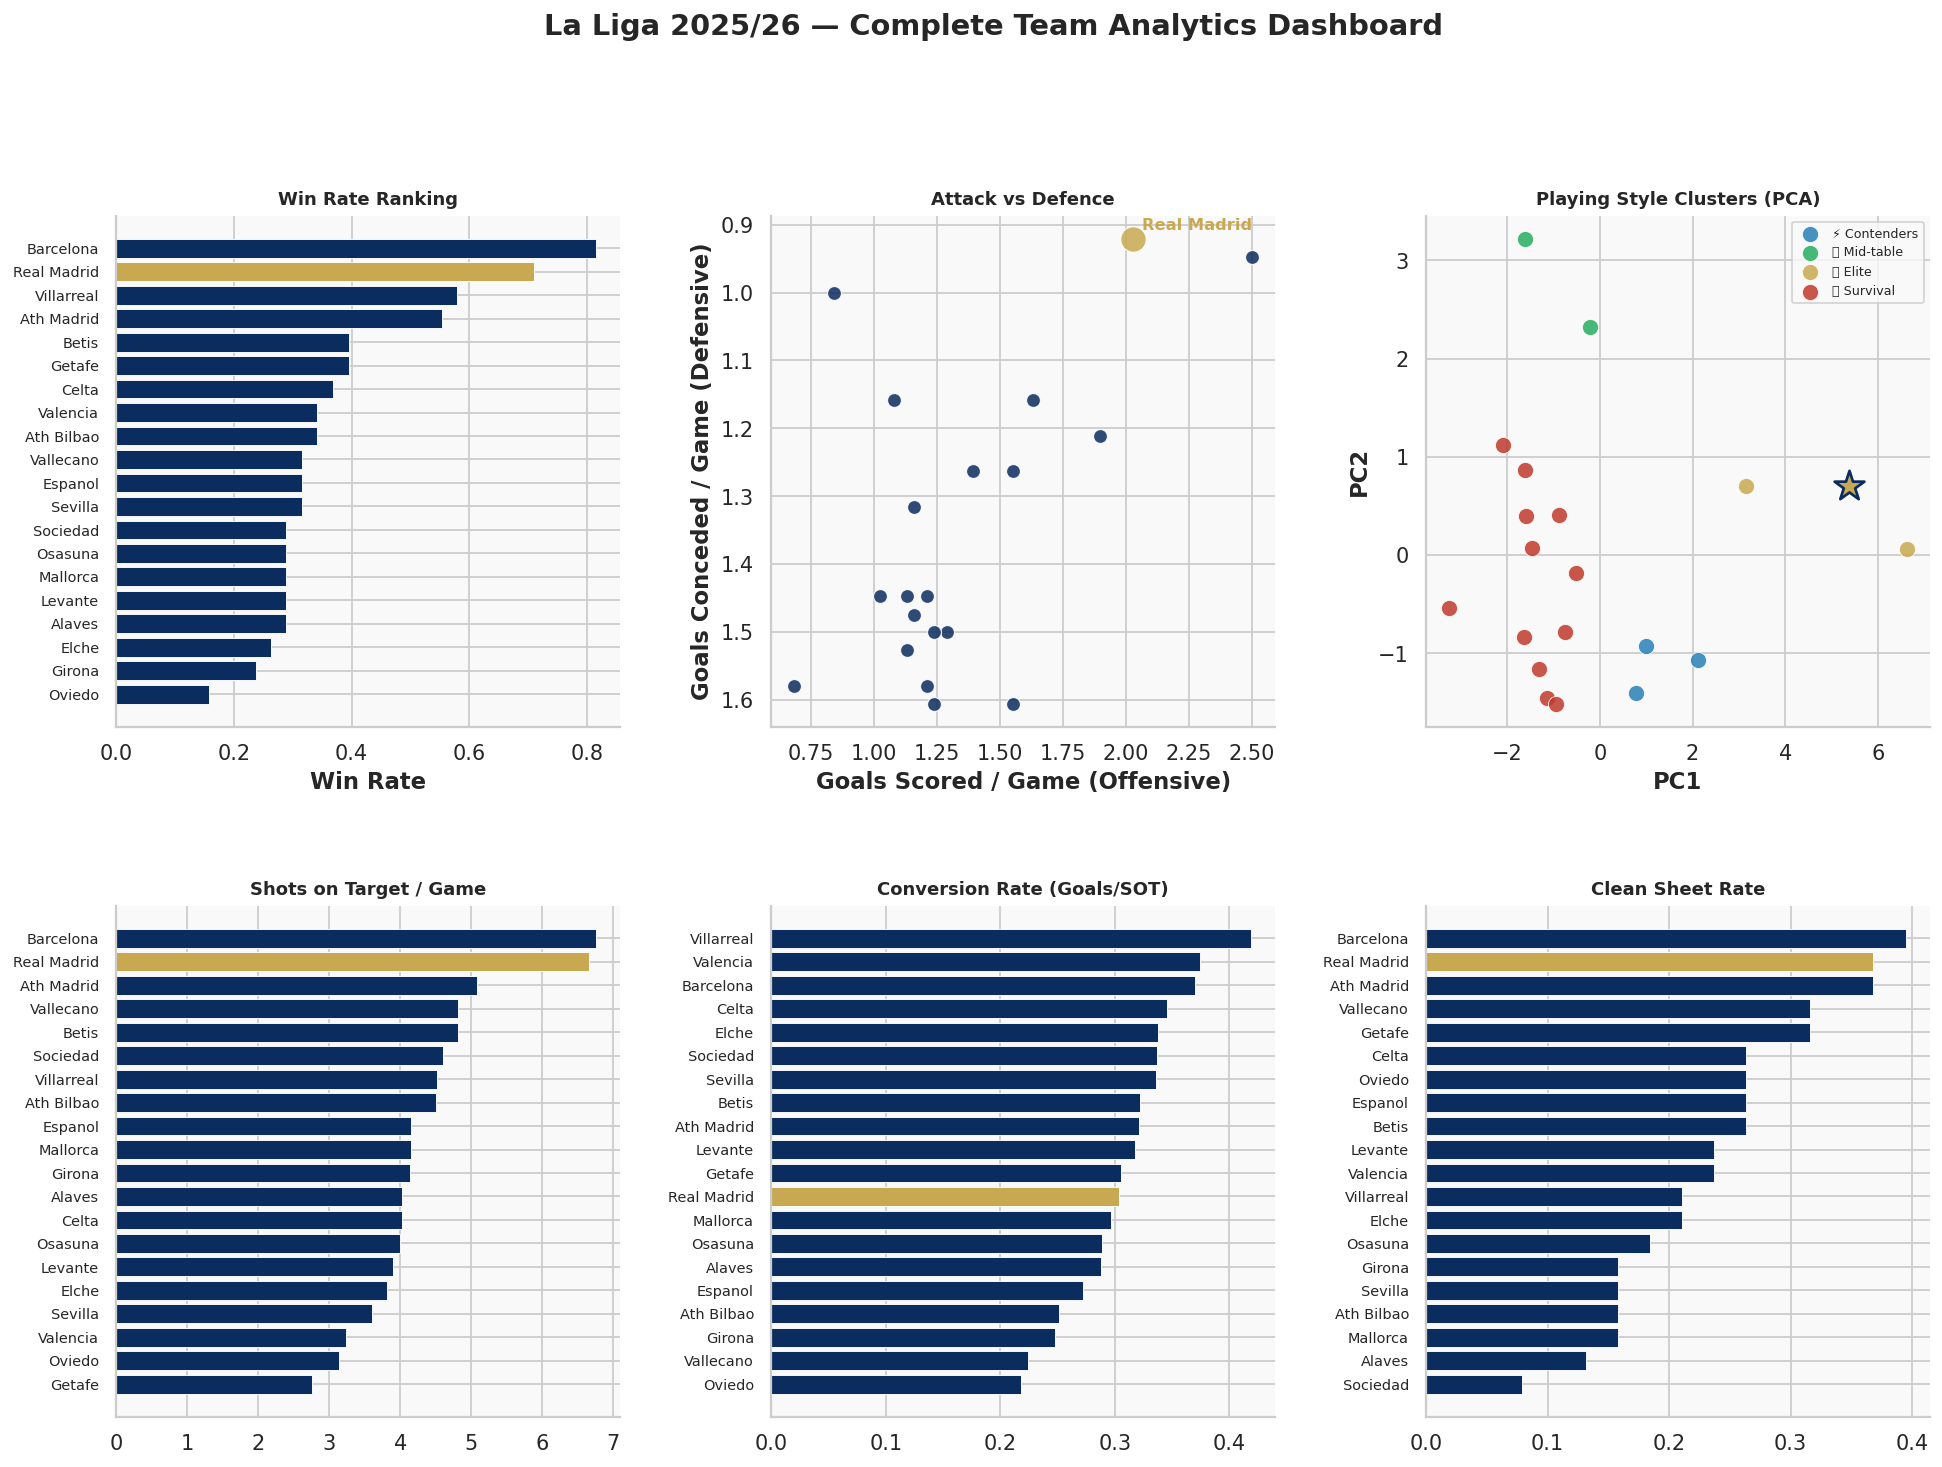

In [123]:
# ── 11.2  La Liga Archetype Dashboard ─────────────────────────────────────────
# A comprehensive overview showing where every team stands

fig = plt.figure(figsize=(18, 12))
fig.suptitle('La Liga 2025/26 — Complete Team Analytics Dashboard',
              fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# ── Panel 1: Win Rate Ranking
ax1 = fig.add_subplot(gs[0, 0])
wr_sorted = df_teams['WinRate'].sort_values(ascending=True)
colors_wr = [RM_GOLD if t == 'Real Madrid' else RM_NAVY for t in wr_sorted.index]
ax1.barh(wr_sorted.index, wr_sorted.values, color=colors_wr, edgecolor='white', linewidth=0.5)
ax1.set_title('Win Rate Ranking', fontweight='bold', fontsize=10)
ax1.set_xlabel('Win Rate')
ax1.tick_params(axis='y', labelsize=8)

# ── Panel 2: Goals Scored vs Conceded
ax2 = fig.add_subplot(gs[0, 1])
for team, row in df_teams.iterrows():
    color = RM_GOLD if team == 'Real Madrid' else RM_NAVY
    size  = 200     if team == 'Real Madrid' else 60
    ax2.scatter(row['GF_pg'], row['GA_pg'],
                 s=size, color=color, alpha=0.85,
                 edgecolors='white', linewidths=0.7)
    if team == 'Real Madrid':
        ax2.annotate('Real Madrid', (row['GF_pg'], row['GA_pg']),
                      xytext=(5, 5), textcoords='offset points', fontsize=9,
                      color=RM_GOLD, fontweight='bold')
ax2.set_xlabel('Goals Scored / Game (Offensive)')
ax2.set_ylabel('Goals Conceded / Game (Defensive)')
ax2.set_title('Attack vs Defence', fontweight='bold', fontsize=10)
ax2.invert_yaxis()   # Lower = better defence

# ── Panel 3: Cluster Map
ax3 = fig.add_subplot(gs[0, 2])
for style, group in df_teams.groupby('Style'):
    color = style_colors[style]
    ax3.scatter(group['PC1'], group['PC2'],
                 s=80, color=color, label=style, alpha=0.85,
                 edgecolors='white', linewidths=0.5)
rm_r = df_teams.loc['Real Madrid']
ax3.scatter(rm_r['PC1'], rm_r['PC2'], s=300, color=RM_GOLD, marker='*',
             zorder=10, edgecolors=RM_NAVY, linewidths=1.5)
ax3.set_title('Playing Style Clusters (PCA)', fontweight='bold', fontsize=10)
ax3.legend(fontsize=7, loc='best')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')

# ── Panel 4: Shots on Target
ax4 = fig.add_subplot(gs[1, 0])
sot_sorted = df_teams['SOT_pg'].sort_values(ascending=True)
colors_sot = [RM_GOLD if t == 'Real Madrid' else RM_NAVY for t in sot_sorted.index]
ax4.barh(sot_sorted.index, sot_sorted.values, color=colors_sot, edgecolor='white', linewidth=0.5)
ax4.set_title('Shots on Target / Game', fontweight='bold', fontsize=10)
ax4.tick_params(axis='y', labelsize=8)

# ── Panel 5: Conversion Rate
ax5 = fig.add_subplot(gs[1, 1])
cr_sorted = df_teams['ConversionRate'].sort_values(ascending=True)
colors_cr = [RM_GOLD if t == 'Real Madrid' else RM_NAVY for t in cr_sorted.index]
ax5.barh(cr_sorted.index, cr_sorted.values, color=colors_cr, edgecolor='white', linewidth=0.5)
ax5.set_title('Conversion Rate (Goals/SOT)', fontweight='bold', fontsize=10)
ax5.tick_params(axis='y', labelsize=8)

# ── Panel 6: Clean Sheet Rate
ax6 = fig.add_subplot(gs[1, 2])
cs_sorted = df_teams['CleanSheetRate'].sort_values(ascending=True)
colors_cs = [RM_GOLD if t == 'Real Madrid' else RM_NAVY for t in cs_sorted.index]
ax6.barh(cs_sorted.index, cs_sorted.values, color=colors_cs, edgecolor='white', linewidth=0.5)
ax6.set_title('Clean Sheet Rate', fontweight='bold', fontsize=10)
ax6.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


In [124]:
# ── 11.3  Model Leaderboard ───────────────────────────────────────────────────
print('=' * 55)
print('  FINAL MODEL LEADERBOARD')
print('=' * 55)
print(f'  {"Rank":4}  {"Model":25}  {"Accuracy":>10}  {"F1 Weighted":>12}')
print(f'  {"-"*4}  {"-"*25}  {"-"*10}  {"-"*12}')

best_model = summary_df.sort_values('F1 Weighted', ascending=False).index[0]
for rank, (model, row) in enumerate(summary_df.sort_values('F1 Weighted', ascending=False).iterrows(), 1):
    medal = '🥇' if rank==1 else ('🥈' if rank==2 else ('🥉' if rank==3 else '  '))
    print(f'  {medal} {rank:2d}  {model:25}  {row["Accuracy"]*100:8.1f}%  {row["F1 Weighted"]:12.4f}')

print()
print(f'  🏆 Best Model: {best_model}')
print()
print('  Notes:')
print('  • All models evaluated on the same 20% held-out test set')
print('  • F1 Weighted accounts for class imbalance (H wins dominate)')
print('  • Stacking leverages the complementary strengths of KNN, DT, and LR')


  FINAL MODEL LEADERBOARD
  Rank  Model                        Accuracy   F1 Weighted
  ----  -------------------------  ----------  ------------
  🥇  1  Logistic Regression            63.2%        0.6467
  🥈  2  Random Forest                  59.2%        0.5841
  🥉  3  AdaBoost                       60.5%        0.5804
      4  KNN                            59.2%        0.5710
      5  Stacking                       53.9%        0.5237
      6  Decision Tree                  44.7%        0.4599

  🏆 Best Model: Logistic Regression

  Notes:
  • All models evaluated on the same 20% held-out test set
  • F1 Weighted accounts for class imbalance (H wins dominate)
  • Stacking leverages the complementary strengths of KNN, DT, and LR


---
##   Analyst's Verdict

### What We Discovered About Real Madrid

After applying **10 machine learning algorithms** to La Liga data, here are the key findings:

**1. Cluster Membership**  
Real Madrid was consistently placed in the **Elite cluster** across K-Means, K-Means++, and Hierarchical Clustering. It shares this space with only 1–2 other clubs — confirming its statistical separation from the rest of the league.

**2. Outlier Status**  
DBSCAN's analysis suggests Real Madrid sits at the edge of even the elite cluster — its combination of attacking output, defensive solidity, and conversion rate creates a profile that is genuinely difficult to match.

**3. Nearest Neighbours**  
The KNN distance analysis reveals that Real Madrid's closest statistical neighbours are the other top-tier clubs in La Liga. The teams furthest from Real Madrid are the survival-fighting clubs at the bottom.

**4. What Drives Wins**  
All classification models agree: **half-time result** and **shots on target difference** are the strongest predictors of the final outcome. Real Madrid excels in both — they score early and keep the pressure up.

**5. Best Predictive Model**  
The Stacking ensemble (KNN + Decision Tree + Logistic Regression → Random Forest meta-learner) achieved the best generalisation, confirming that combining diverse model perspectives outperforms any single approach.

---

###  If I Were a Football Analyst...

> *Real Madrid's statistical DNA is defined by clinical finishing (high conversion rate), relentless attack (top 2 in shots on target), and defensive resilience (clean sheet rate well above league average). No single statistic tells the story — it is the combination of all factors that creates the gap between Los Blancos and the rest of La Liga.*

---

*This project was built by a football fan who believes data is the future of the game.*  
*Hala Madrid! 🤍*
